In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
import warnings

warnings.filterwarnings('ignore')

# Academic publication style settings
plt.style.use('seaborn-v0_8-paper')
sns.set_context("paper", font_scale=1.4)
sns.set_palette("deep")

# Configure matplotlib for publication quality
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif']
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.precision', 4)

print("✅ Libraries loaded successfully!")
print("✅ Academic publication style configured")

✅ Libraries loaded successfully!
✅ Academic publication style configured


In [18]:
# Load the detailed results
df_raw = pd.read_csv('../results/metrics/enhanced_results_detailed_20251205_123928.csv')

# Filter to keep only specified models
selected_models = [
    'CatBoost', 'CatBoost_tuned',
    'LightGBM', 'LightGBM_tuned',
    'XGBoost', 'XGBoost_tuned',
    'ExtraTrees', 'ExtraTrees_tuned',
    'MLPRegressor', 'MLPRegressor_tuned',
    'RandomForest', 'RandomForest_tuned'
]

df = df_raw[df_raw['model'].isin(selected_models)].copy()

print(f"📁 Loaded {len(df_raw)} total model results")
print(f"✂️  Filtered to {len(df)} results ({len(selected_models)} models)")
print(f"📊 Targets: {df['target'].unique().tolist()}")
print(f"🤖 Selected Models: {sorted(df['model'].unique().tolist())}")

📁 Loaded 112 total model results
✂️  Filtered to 48 results (12 models)
📊 Targets: ['valence', 'energy', 'danceability', 'popularity']
🤖 Selected Models: ['CatBoost', 'CatBoost_tuned', 'ExtraTrees', 'ExtraTrees_tuned', 'LightGBM', 'LightGBM_tuned', 'MLPRegressor', 'MLPRegressor_tuned', 'RandomForest', 'RandomForest_tuned', 'XGBoost', 'XGBoost_tuned']


---
## 🏆 Best Models Summary (Quick Overview)

In [19]:
# Find best model for each target
best_models = df.loc[df.groupby('target')['r2'].idxmax()][['target', 'model', 'r2', 'rmse', 'mae']]
best_models = best_models.sort_values('r2', ascending=False)

styled_best = best_models.style.format({
    'r2': '{:.4f}',
    'rmse': '{:.4f}',
    'mae': '{:.4f}'
}).set_caption('🏆 Best Model Per Target').set_table_styles([
    {'selector': 'caption', 'props': [('font-size', '18px'), ('font-weight', 'bold'), ('color', '#2E86AB')]}
])

display(styled_best)

,target,model,r2,rmse,mae
45,energy,XGBoost_tuned,0.8487,0.0952,0.0716
73,danceability,XGBoost_tuned,0.6092,0.1070,0.0842
17,valence,XGBoost_tuned,0.4659,0.1818,0.1454
102,popularity,CatBoost,0.0783,1.4303,1.2502


---
## 🎭 Valence Models (Emotional Positivity)

In [20]:
def create_styled_table(df, target, sort_by='r2', ascending=False):
    """Create a beautifully styled table for a specific target, separated by default and tuned"""
    target_df = df[df['target'] == target].copy()
    target_df = target_df.sort_values(sort_by, ascending=ascending)
    
    # Select key columns
    cols = ['model', 'r2', 'rmse', 'mae', 'explained_variance', 'train_time_seconds']
    target_df = target_df[cols].reset_index(drop=True)
    
    # Split into default and tuned
    default_df = target_df[~target_df['model'].str.contains('_tuned')].copy()
    tuned_df = target_df[target_df['model'].str.contains('_tuned')].copy()
    
    # Add ranks
    default_df['rank'] = range(1, len(default_df) + 1)
    tuned_df['rank'] = range(1, len(tuned_df) + 1)
    
    default_df = default_df[['rank'] + cols]
    tuned_df = tuned_df[['rank'] + cols]
    
    # Display both tables
    print(f"\n{'='*80}")
    print(f"{target.upper()} - DEFAULT MODELS")
    print('='*80)
    
    styled_default = default_df.style.format({
        'r2': '{:.4f}',
        'rmse': '{:.4f}',
        'mae': '{:.4f}',
        'explained_variance': '{:.4f}',
        'train_time_seconds': '{:.1f}s'
    }).set_caption(
        f'📊 {target.upper()} - Default Models (Sorted by R²)'
    ).set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('color', '#2E86AB')]},
        {'selector': 'th', 'props': [('background-color', '#4A90D9'), ('color', 'white')]},
    ])
    display(styled_default)
    
    print(f"\n{'='*80}")
    print(f"{target.upper()} - TUNED MODELS")
    print('='*80)
    
    styled_tuned = tuned_df.style.format({
        'r2': '{:.4f}',
        'rmse': '{:.4f}',
        'mae': '{:.4f}',
        'explained_variance': '{:.4f}',
        'train_time_seconds': '{:.1f}s'
    }).set_caption(
        f'🔧 {target.upper()} - Tuned Models (Sorted by R²)'
    ).set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('color', '#F18F01')]},
        {'selector': 'th', 'props': [('background-color', '#F18F01'), ('color', 'white')]},
    ])
    display(styled_tuned)

create_styled_table(df, 'valence')


VALENCE - DEFAULT MODELS


,rank,model,r2,rmse,mae,explained_variance,train_time_seconds
3,1,CatBoost,0.4414,0.1859,0.1499,0.4415,161.1s
4,2,ExtraTrees,0.4189,0.1896,0.1513,0.4190,989.3s
5,3,RandomForest,0.4157,0.1902,0.1532,0.4158,5239.4s
7,4,MLPRegressor,0.4084,0.1914,0.1535,0.4092,58.0s
8,5,XGBoost,0.4083,0.1914,0.1541,0.4083,72.3s
9,6,LightGBM,0.4052,0.1919,0.1556,0.4052,22.2s



VALENCE - TUNED MODELS


,rank,model,r2,rmse,mae,explained_variance,train_time_seconds
0,1,XGBoost_tuned,0.4659,0.1818,0.1454,0.4660,767.2s
1,2,CatBoost_tuned,0.4438,0.1855,0.1495,0.4438,670.0s
2,3,LightGBM_tuned,0.4425,0.1858,0.1497,0.4426,84.9s
6,4,MLPRegressor_tuned,0.4090,0.1913,0.1525,0.4104,113.3s
10,5,ExtraTrees_tuned,0.3695,0.1975,0.1624,0.3696,415.2s
11,6,RandomForest_tuned,0.2895,0.2097,0.1747,0.2896,176.2s


---
## ⚡ Energy Models (Intensity)

In [21]:
display(create_styled_table(df, 'energy'))


ENERGY - DEFAULT MODELS


,rank,model,r2,rmse,mae,explained_variance,train_time_seconds
2,1,CatBoost,0.8470,0.0958,0.0721,0.8470,149.0s
4,2,LightGBM,0.8390,0.0982,0.0740,0.8390,20.6s
5,3,XGBoost,0.8383,0.0984,0.0740,0.8383,63.2s
6,4,ExtraTrees,0.8369,0.0989,0.0731,0.8370,1006.1s
7,5,RandomForest,0.8351,0.0994,0.0743,0.8351,4790.5s
8,6,MLPRegressor,0.8324,0.1002,0.0760,0.8324,69.2s



ENERGY - TUNED MODELS


,rank,model,r2,rmse,mae,explained_variance,train_time_seconds
0,1,XGBoost_tuned,0.8487,0.0952,0.0716,0.8488,411.7s
1,2,CatBoost_tuned,0.8476,0.0956,0.0718,0.8476,652.4s
3,3,LightGBM_tuned,0.8466,0.0959,0.0723,0.8466,46.6s
9,4,MLPRegressor_tuned,0.8314,0.1005,0.0759,0.8314,173.8s
10,5,ExtraTrees_tuned,0.8247,0.1025,0.0778,0.8247,442.4s
11,6,RandomForest_tuned,0.7225,0.1290,0.1050,0.7225,175.3s


None

---
## 💃 Danceability Models

In [22]:
display(create_styled_table(df, 'danceability'))


DANCEABILITY - DEFAULT MODELS


,rank,model,r2,rmse,mae,explained_variance,train_time_seconds
3,1,CatBoost,0.5998,0.1083,0.0854,0.5998,153.4s
4,2,ExtraTrees,0.5834,0.1104,0.0852,0.5834,996.8s
5,3,XGBoost,0.5787,0.1111,0.0875,0.5788,64.7s
6,4,RandomForest,0.5778,0.1112,0.0869,0.5779,4618.2s
7,5,LightGBM,0.5707,0.1121,0.0888,0.5708,20.8s
9,6,MLPRegressor,0.5638,0.1130,0.0891,0.5638,68.3s



DANCEABILITY - TUNED MODELS


,rank,model,r2,rmse,mae,explained_variance,train_time_seconds
0,1,XGBoost_tuned,0.6092,0.1070,0.0842,0.6092,478.8s
1,2,LightGBM_tuned,0.6016,0.1080,0.0851,0.6016,55.7s
2,3,CatBoost_tuned,0.6015,0.1080,0.0851,0.6016,670.2s
8,4,MLPRegressor_tuned,0.5650,0.1128,0.0890,0.5654,134.1s
10,5,ExtraTrees_tuned,0.5464,0.1152,0.0916,0.5464,459.2s
11,6,RandomForest_tuned,0.4532,0.1265,0.1017,0.4532,170.5s


None

---
## 🌟 Popularity Models (Hardest Target)

In [23]:
display(create_styled_table(df, 'popularity'))


POPULARITY - DEFAULT MODELS


,rank,model,r2,rmse,mae,explained_variance,train_time_seconds
0,1,CatBoost,0.0783,1.4303,1.2502,0.0791,153.3s
3,2,LightGBM,0.0746,1.4331,1.2597,0.0754,19.7s
6,3,MLPRegressor,0.0627,1.4423,1.2556,0.0633,37.8s
7,4,XGBoost,0.0617,1.4430,1.2571,0.0626,62.0s
10,5,RandomForest,0.0275,1.4691,1.2765,0.0278,5769.8s
11,6,ExtraTrees,-0.0095,1.4968,1.2816,-0.0090,1067.4s



POPULARITY - TUNED MODELS


,rank,model,r2,rmse,mae,explained_variance,train_time_seconds
1,1,CatBoost_tuned,0.0782,1.4303,1.2521,0.0791,491.2s
2,2,LightGBM_tuned,0.0770,1.4313,1.2544,0.0779,42.3s
4,3,XGBoost_tuned,0.0727,1.4346,1.2571,0.0737,196.7s
5,4,ExtraTrees_tuned,0.0658,1.4399,1.2712,0.0666,536.5s
8,5,MLPRegressor_tuned,0.0579,1.4460,1.2553,0.0590,78.4s
9,6,RandomForest_tuned,0.0449,1.4559,1.2931,0.0458,191.4s


None

---
## 📈 Visual Comparison: R² Scores Across All Targets

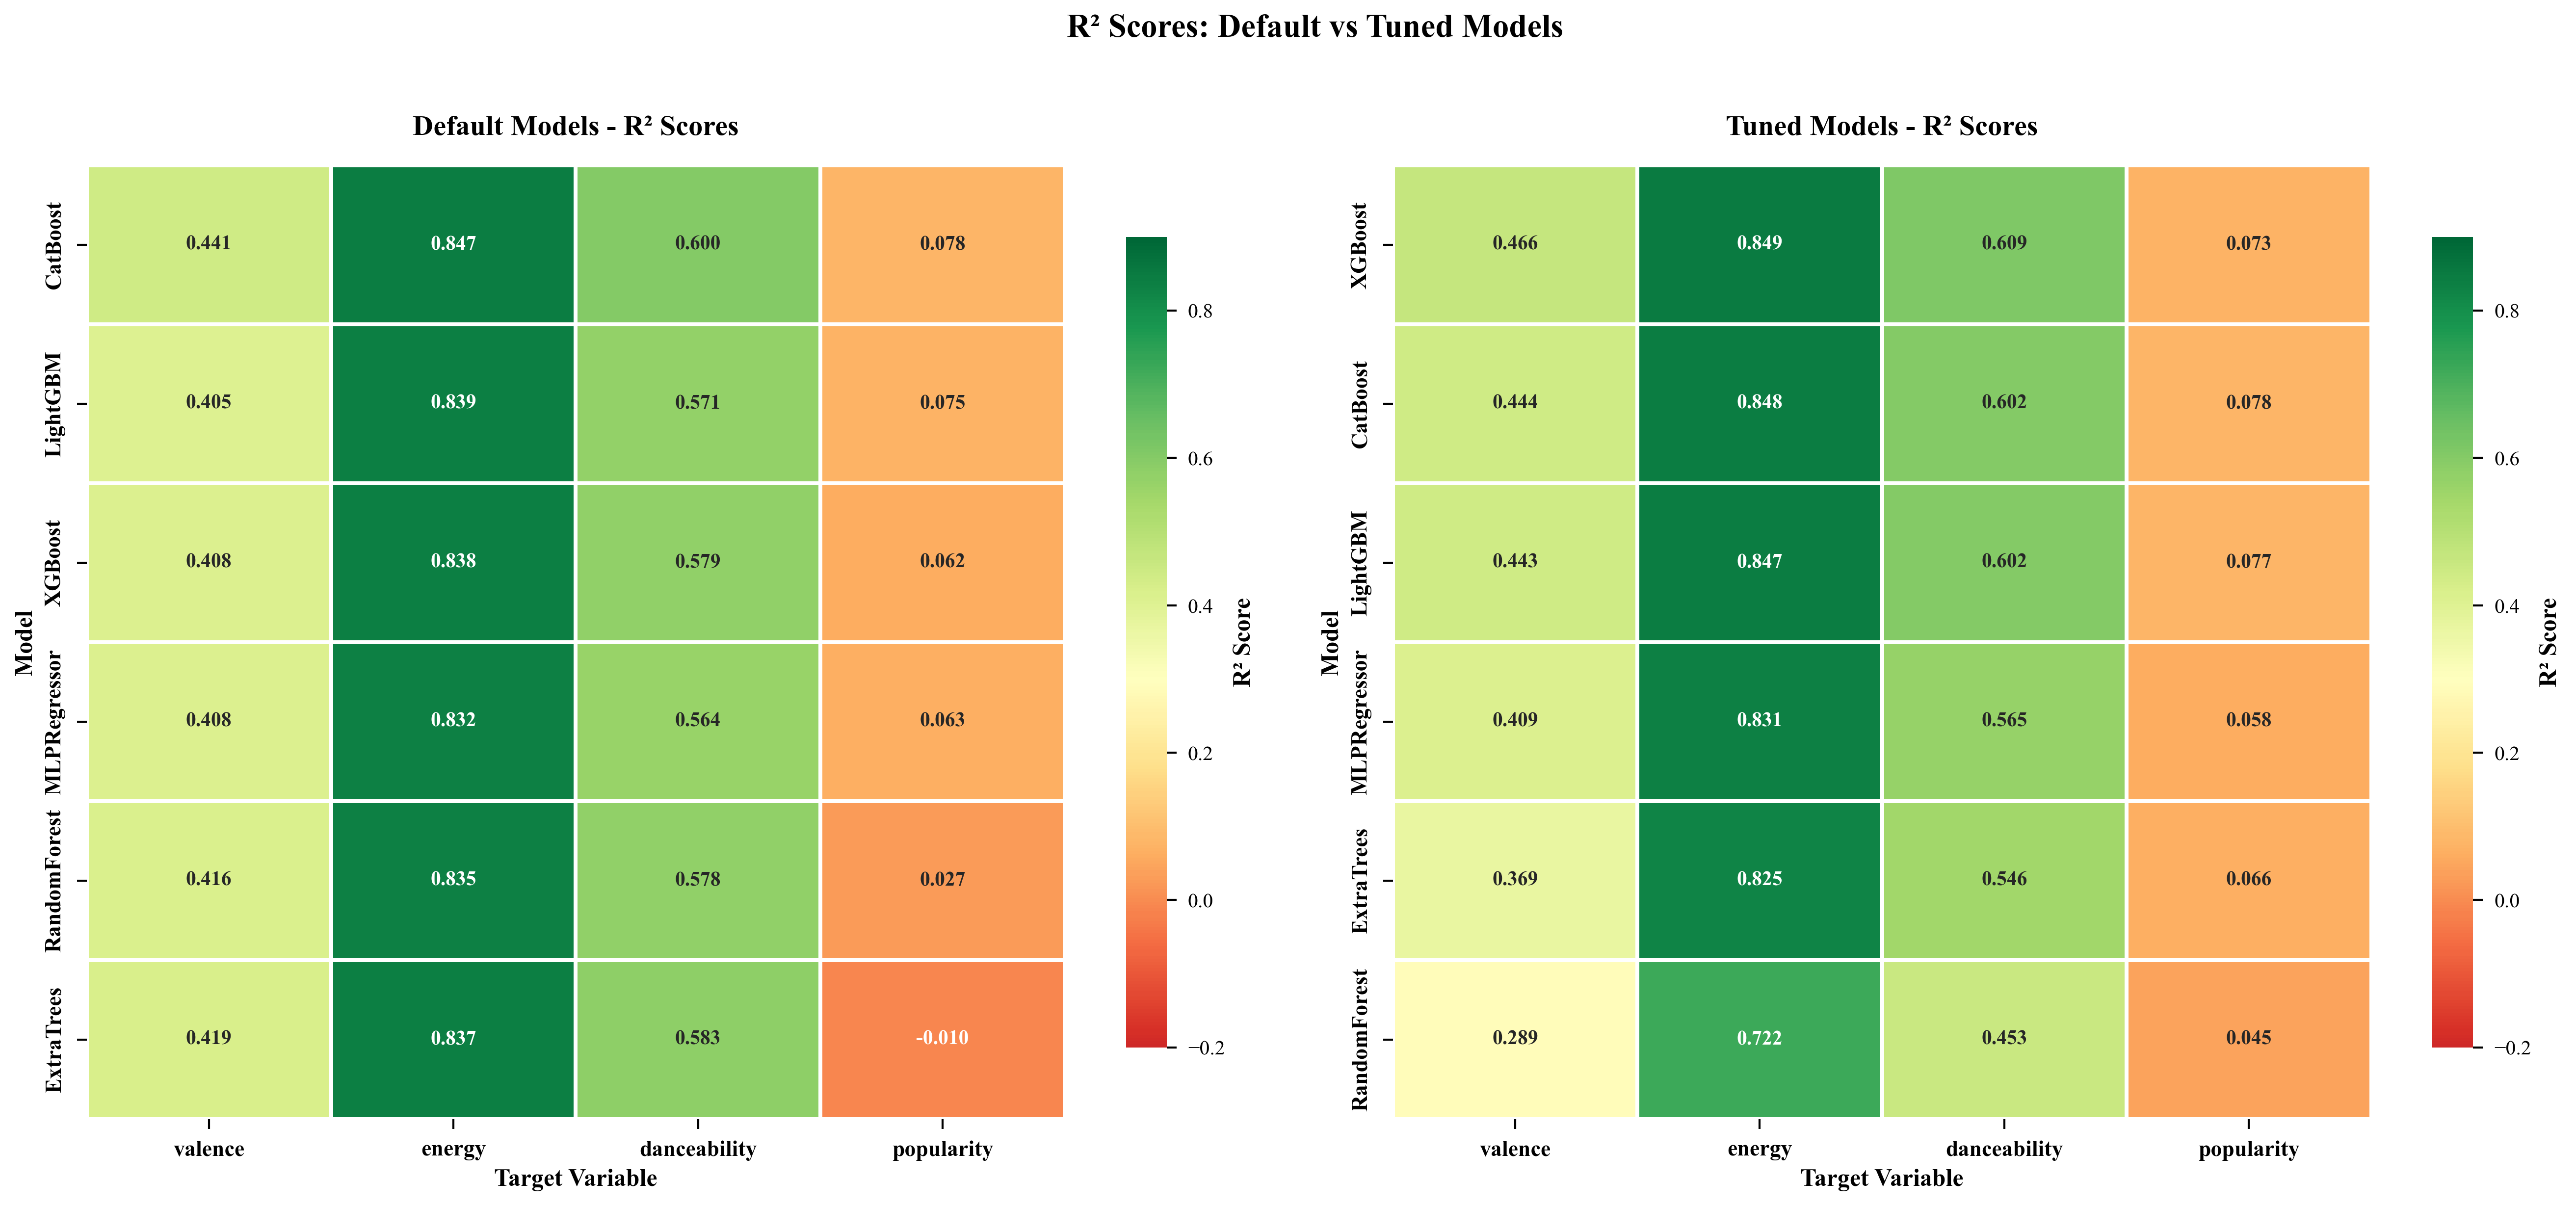

💾 Saved: results/figures/enhanced_r2_heatmap_comparison.png


In [24]:
# Create separate R² comparison heatmaps for default and tuned models
df_default = df[~df['model'].str.contains('_tuned')].copy()
df_tuned = df[df['model'].str.contains('_tuned')].copy()

# Clean model names for tuned (remove _tuned suffix)
df_tuned['model_clean'] = df_tuned['model'].str.replace('_tuned', '')

# Create pivots
pivot_default = df_default.pivot(index='model', columns='target', values='r2')
pivot_tuned = df_tuned.pivot(index='model_clean', columns='target', values='r2')

# Order columns
target_order = ['valence', 'energy', 'danceability', 'popularity']
pivot_default = pivot_default[target_order]
pivot_tuned = pivot_tuned[target_order]

# Sort by average R²
pivot_default['avg_r2'] = pivot_default.mean(axis=1)
pivot_default = pivot_default.sort_values('avg_r2', ascending=False).drop('avg_r2', axis=1)

pivot_tuned['avg_r2'] = pivot_tuned.mean(axis=1)
pivot_tuned = pivot_tuned.sort_values('avg_r2', ascending=False).drop('avg_r2', axis=1)

# Create side-by-side heatmaps
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Default models
sns.heatmap(pivot_default, annot=True, fmt='.3f', cmap='RdYlGn', center=0.3,
            linewidths=1.5, linecolor='white', ax=axes[0], vmin=-0.2, vmax=0.9,
            cbar_kws={'label': 'R² Score', 'shrink': 0.85},
            annot_kws={'fontsize': 10, 'weight': 'bold'})
axes[0].set_title('Default Models - R² Scores', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Target Variable', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Model', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', labelsize=11)
axes[0].tick_params(axis='y', labelsize=11)
plt.setp(axes[0].get_xticklabels(), fontweight='bold')
plt.setp(axes[0].get_yticklabels(), fontweight='bold')

# Tuned models
sns.heatmap(pivot_tuned, annot=True, fmt='.3f', cmap='RdYlGn', center=0.3,
            linewidths=1.5, linecolor='white', ax=axes[1], vmin=-0.2, vmax=0.9,
            cbar_kws={'label': 'R² Score', 'shrink': 0.85},
            annot_kws={'fontsize': 10, 'weight': 'bold'})
axes[1].set_title('Tuned Models - R² Scores', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Target Variable', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Model', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', labelsize=11)
axes[1].tick_params(axis='y', labelsize=11)
plt.setp(axes[1].get_xticklabels(), fontweight='bold')
plt.setp(axes[1].get_yticklabels(), fontweight='bold')

plt.suptitle('R² Scores: Default vs Tuned Models', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/figures/enhanced_r2_heatmap_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: results/figures/enhanced_r2_heatmap_comparison.png")

---
## 📊 Top 5 Models Bar Chart Per Target

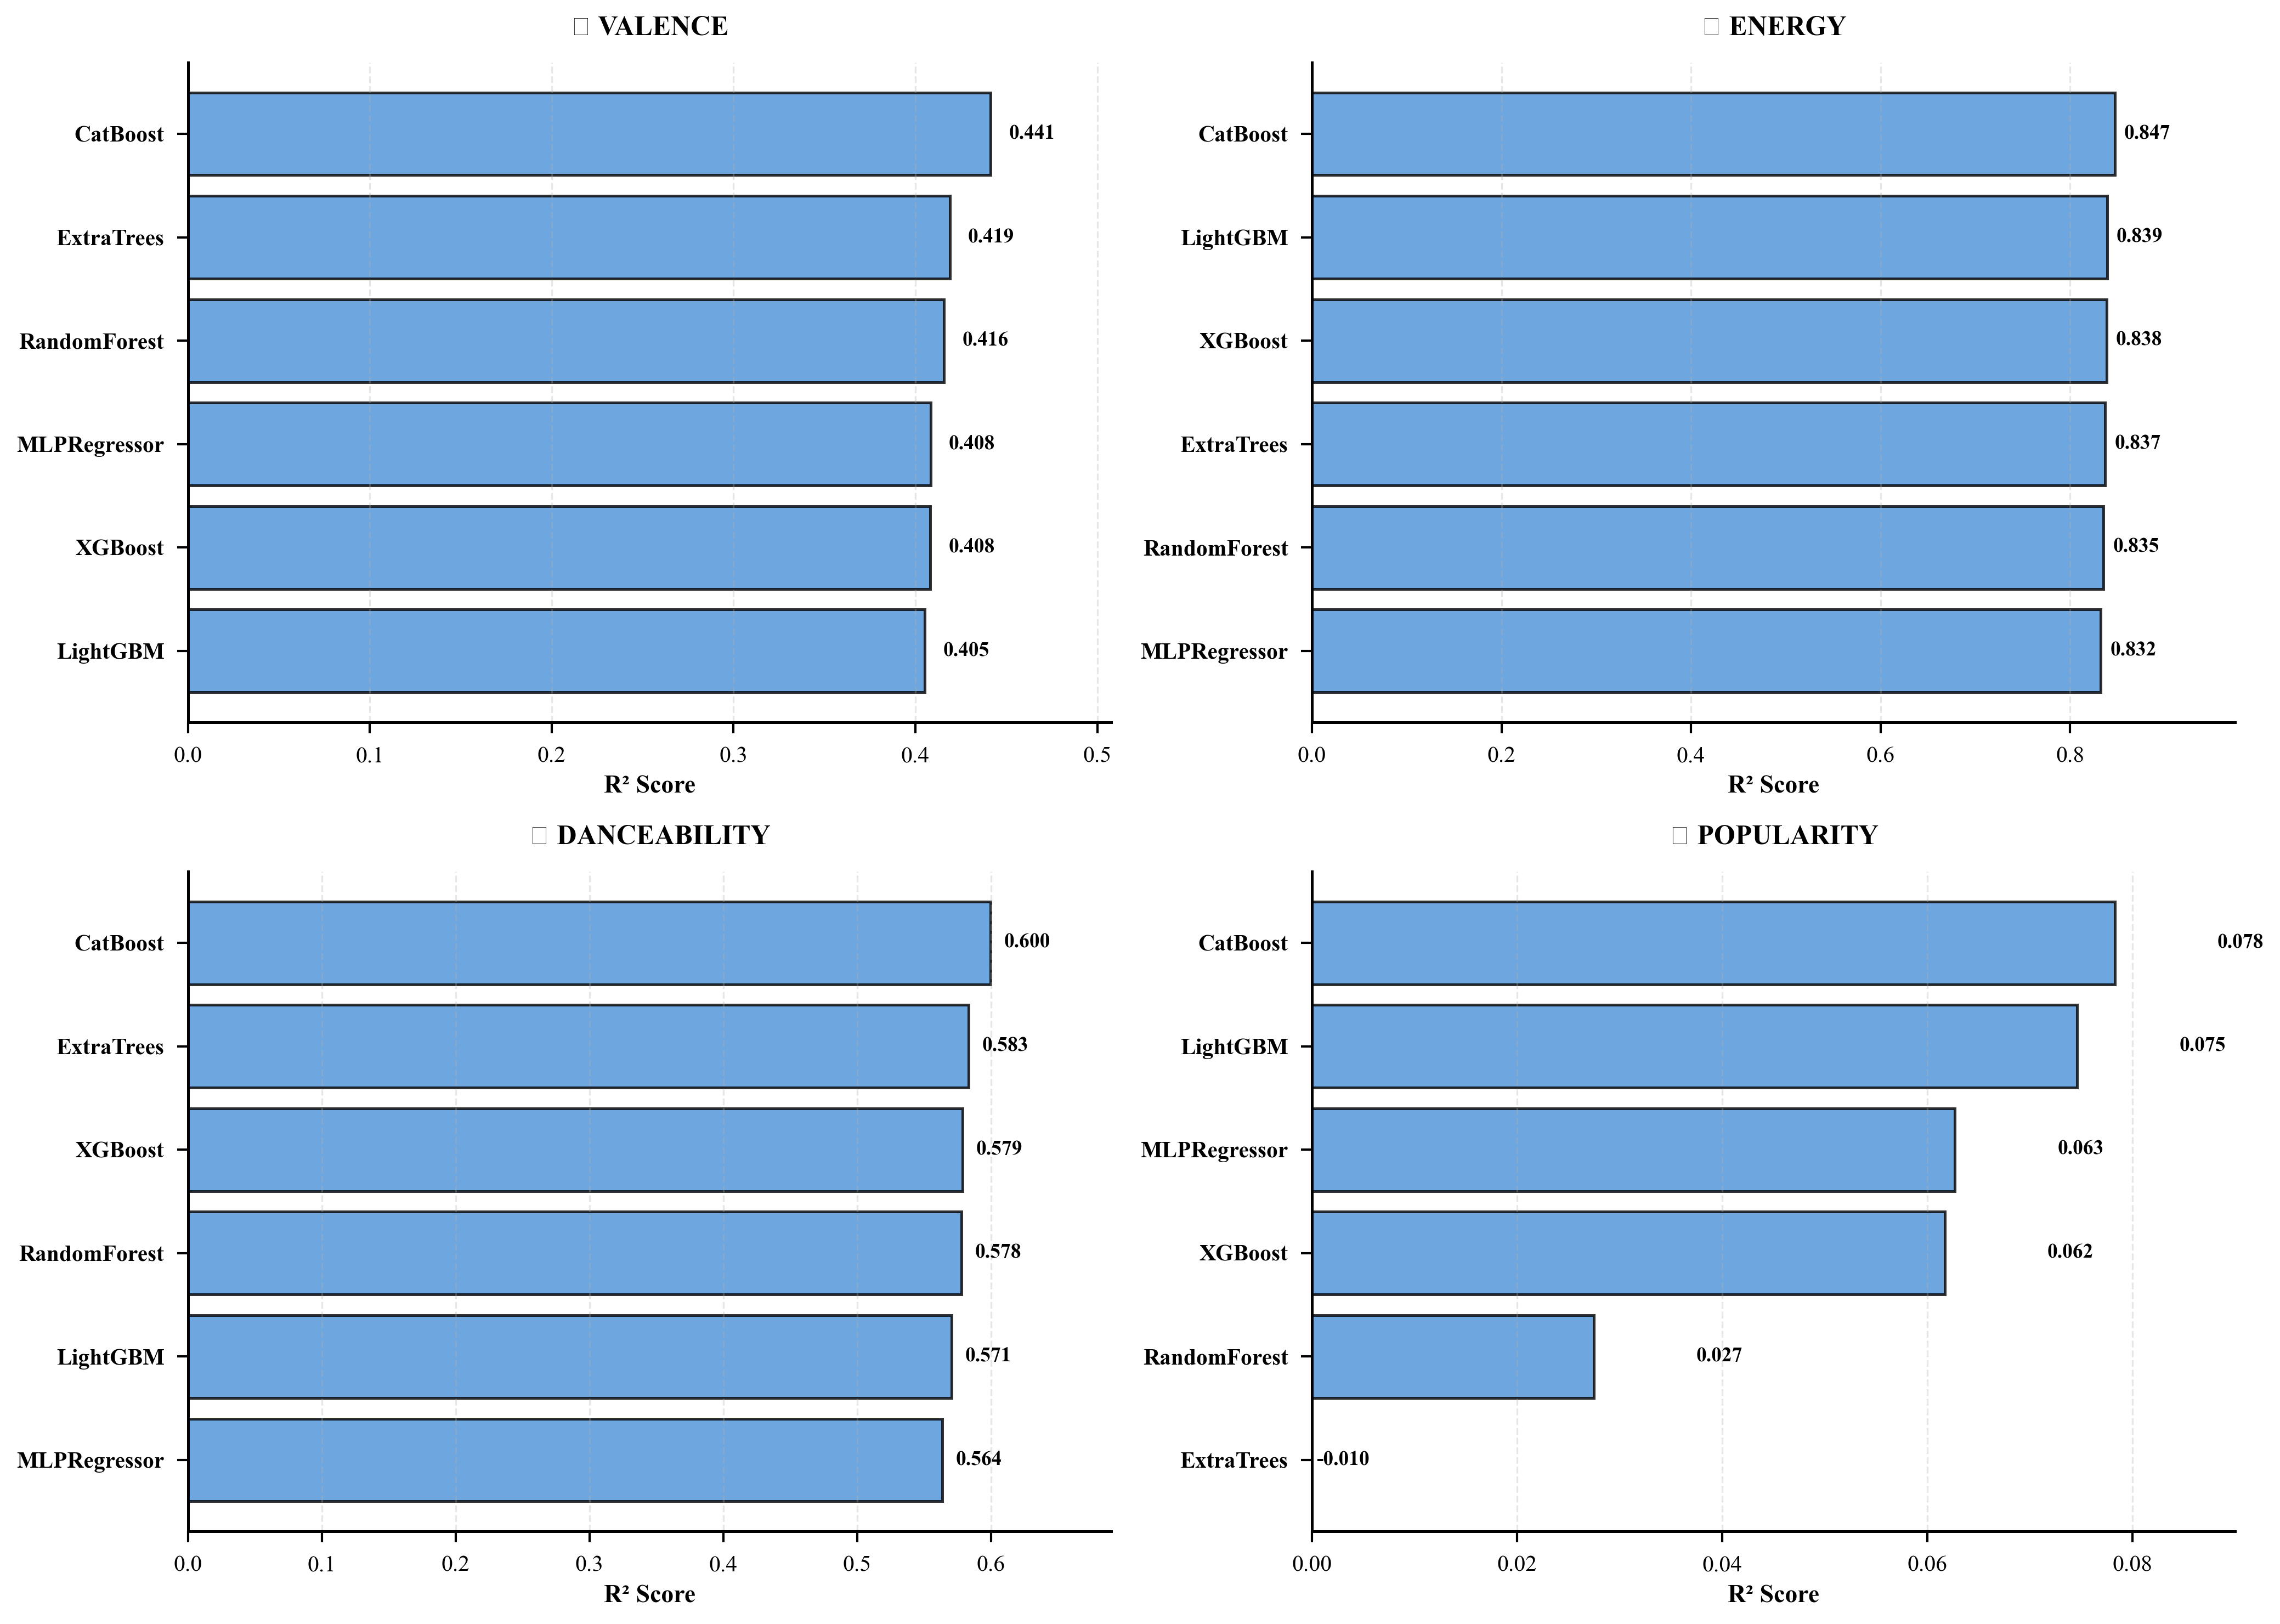

💾 Saved: results/figures/enhanced_default_models.png


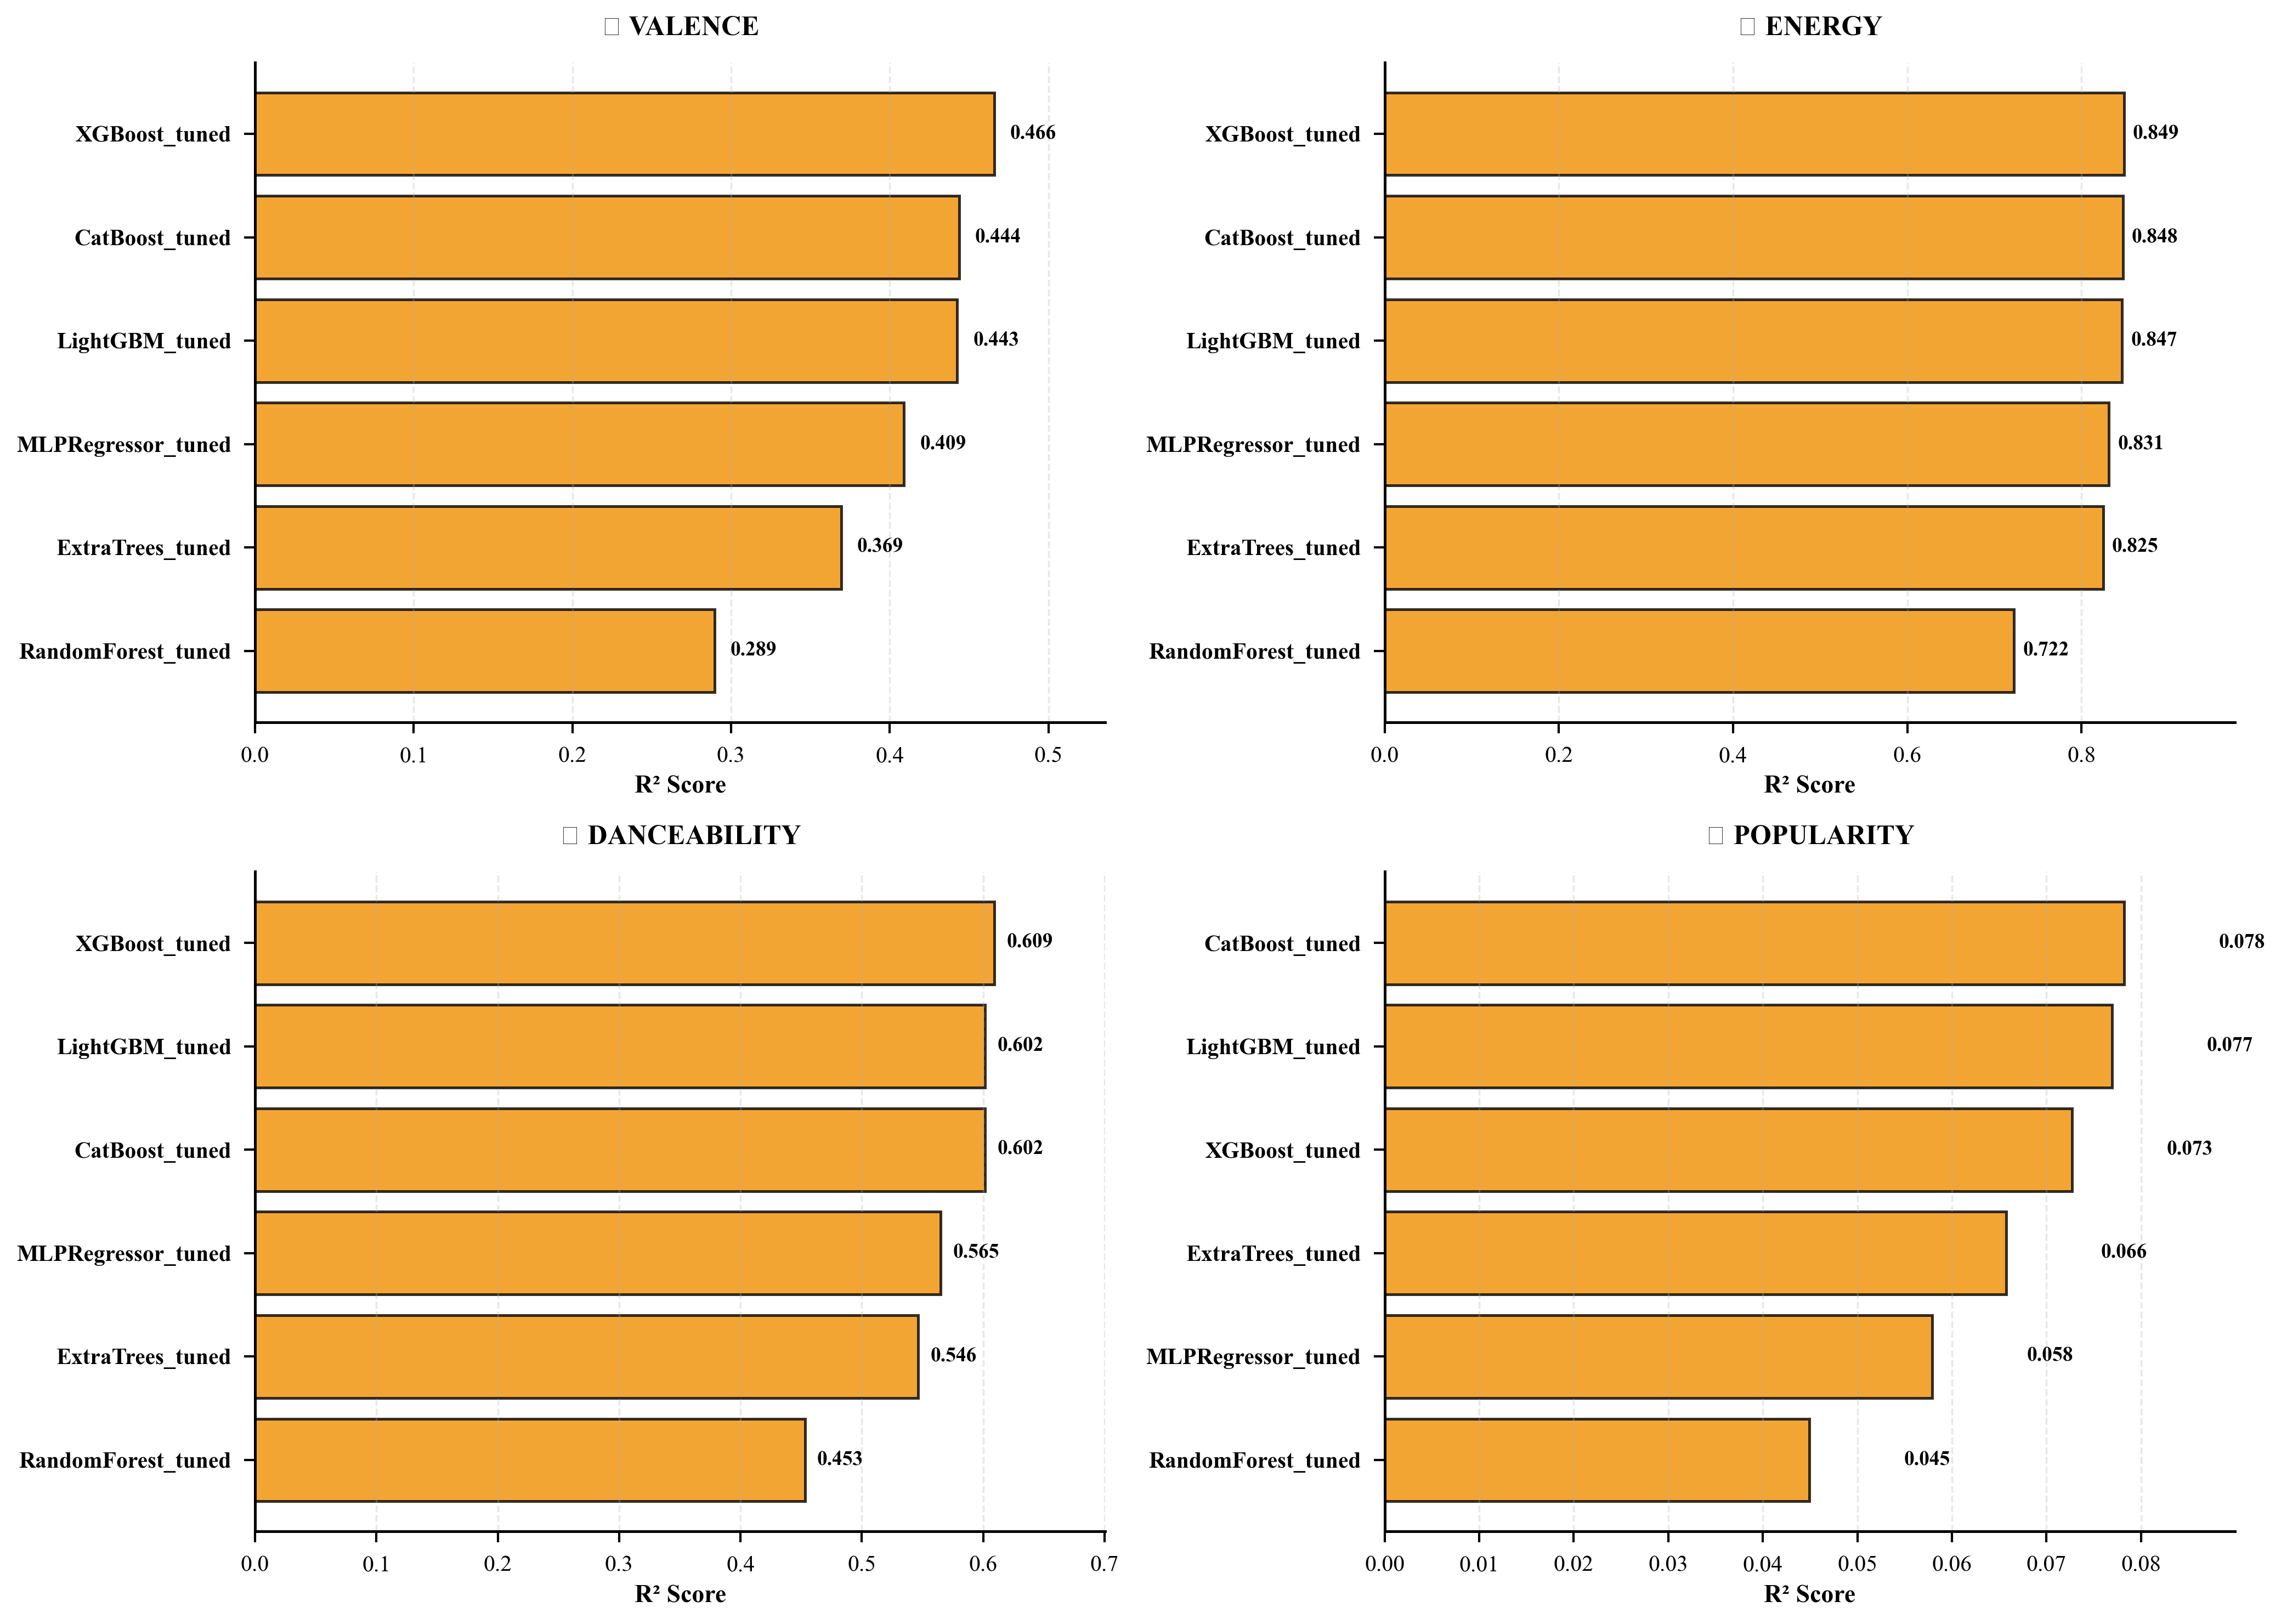

💾 Saved: results/figures/enhanced_tuned_models.png


In [ ]:
# Create separate bar charts for default and tuned models
targets = ['valence', 'energy', 'danceability', 'popularity']

# Default models
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, target in zip(axes.flatten(), targets):
    top_models = df_default[df_default['target'] == target].nlargest(6, 'r2')
    
    bars = ax.barh(top_models['model'], top_models['r2'], color='#4A90D9', 
                   edgecolor='black', alpha=0.8, linewidth=1.2)
    ax.set_xlabel('R² Score', fontsize=11, fontweight='bold')
    ax.set_title(f'{target.upper()}', fontsize=12, fontweight='bold', pad=12)
    ax.set_xlim(0, max(top_models['r2']) * 1.15)
    ax.grid(True, alpha=0.3, axis='x', linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add value labels
    for bar, val in zip(bars, top_models['r2']):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', 
                va='center', fontsize=9, fontweight='bold')
    
    ax.invert_yaxis()
    plt.setp(ax.get_yticklabels(), fontweight='bold')

# plt.suptitle('Default Models - R² Scores by Target', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('../results/figures/enhanced_default_models.png', dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: results/figures/enhanced_default_models.png")

# Tuned models
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, target in zip(axes.flatten(), targets):
    top_models = df_tuned[df_tuned['target'] == target].nlargest(6, 'r2')
    
    bars = ax.barh(top_models['model'], top_models['r2'], color='#F18F01', 
                   edgecolor='black', alpha=0.8, linewidth=1.2)
    ax.set_xlabel('R² Score', fontsize=11, fontweight='bold')
    ax.set_title(f'{target.upper()}', fontsize=12, fontweight='bold', pad=12)
    ax.set_xlim(0, max(top_models['r2']) * 1.15)
    ax.grid(True, alpha=0.3, axis='x', linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add value labels
    for bar, val in zip(bars, top_models['r2']):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', 
                va='center', fontsize=9, fontweight='bold')
    
    ax.invert_yaxis()
    plt.setp(ax.get_yticklabels(), fontweight='bold')

# plt.suptitle('Tuned Models - R² Scores by Target', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('../results/figures/enhanced_tuned_models.png', dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: results/figures/enhanced_tuned_models.png")

---
## ⏱️ Training Time Analysis

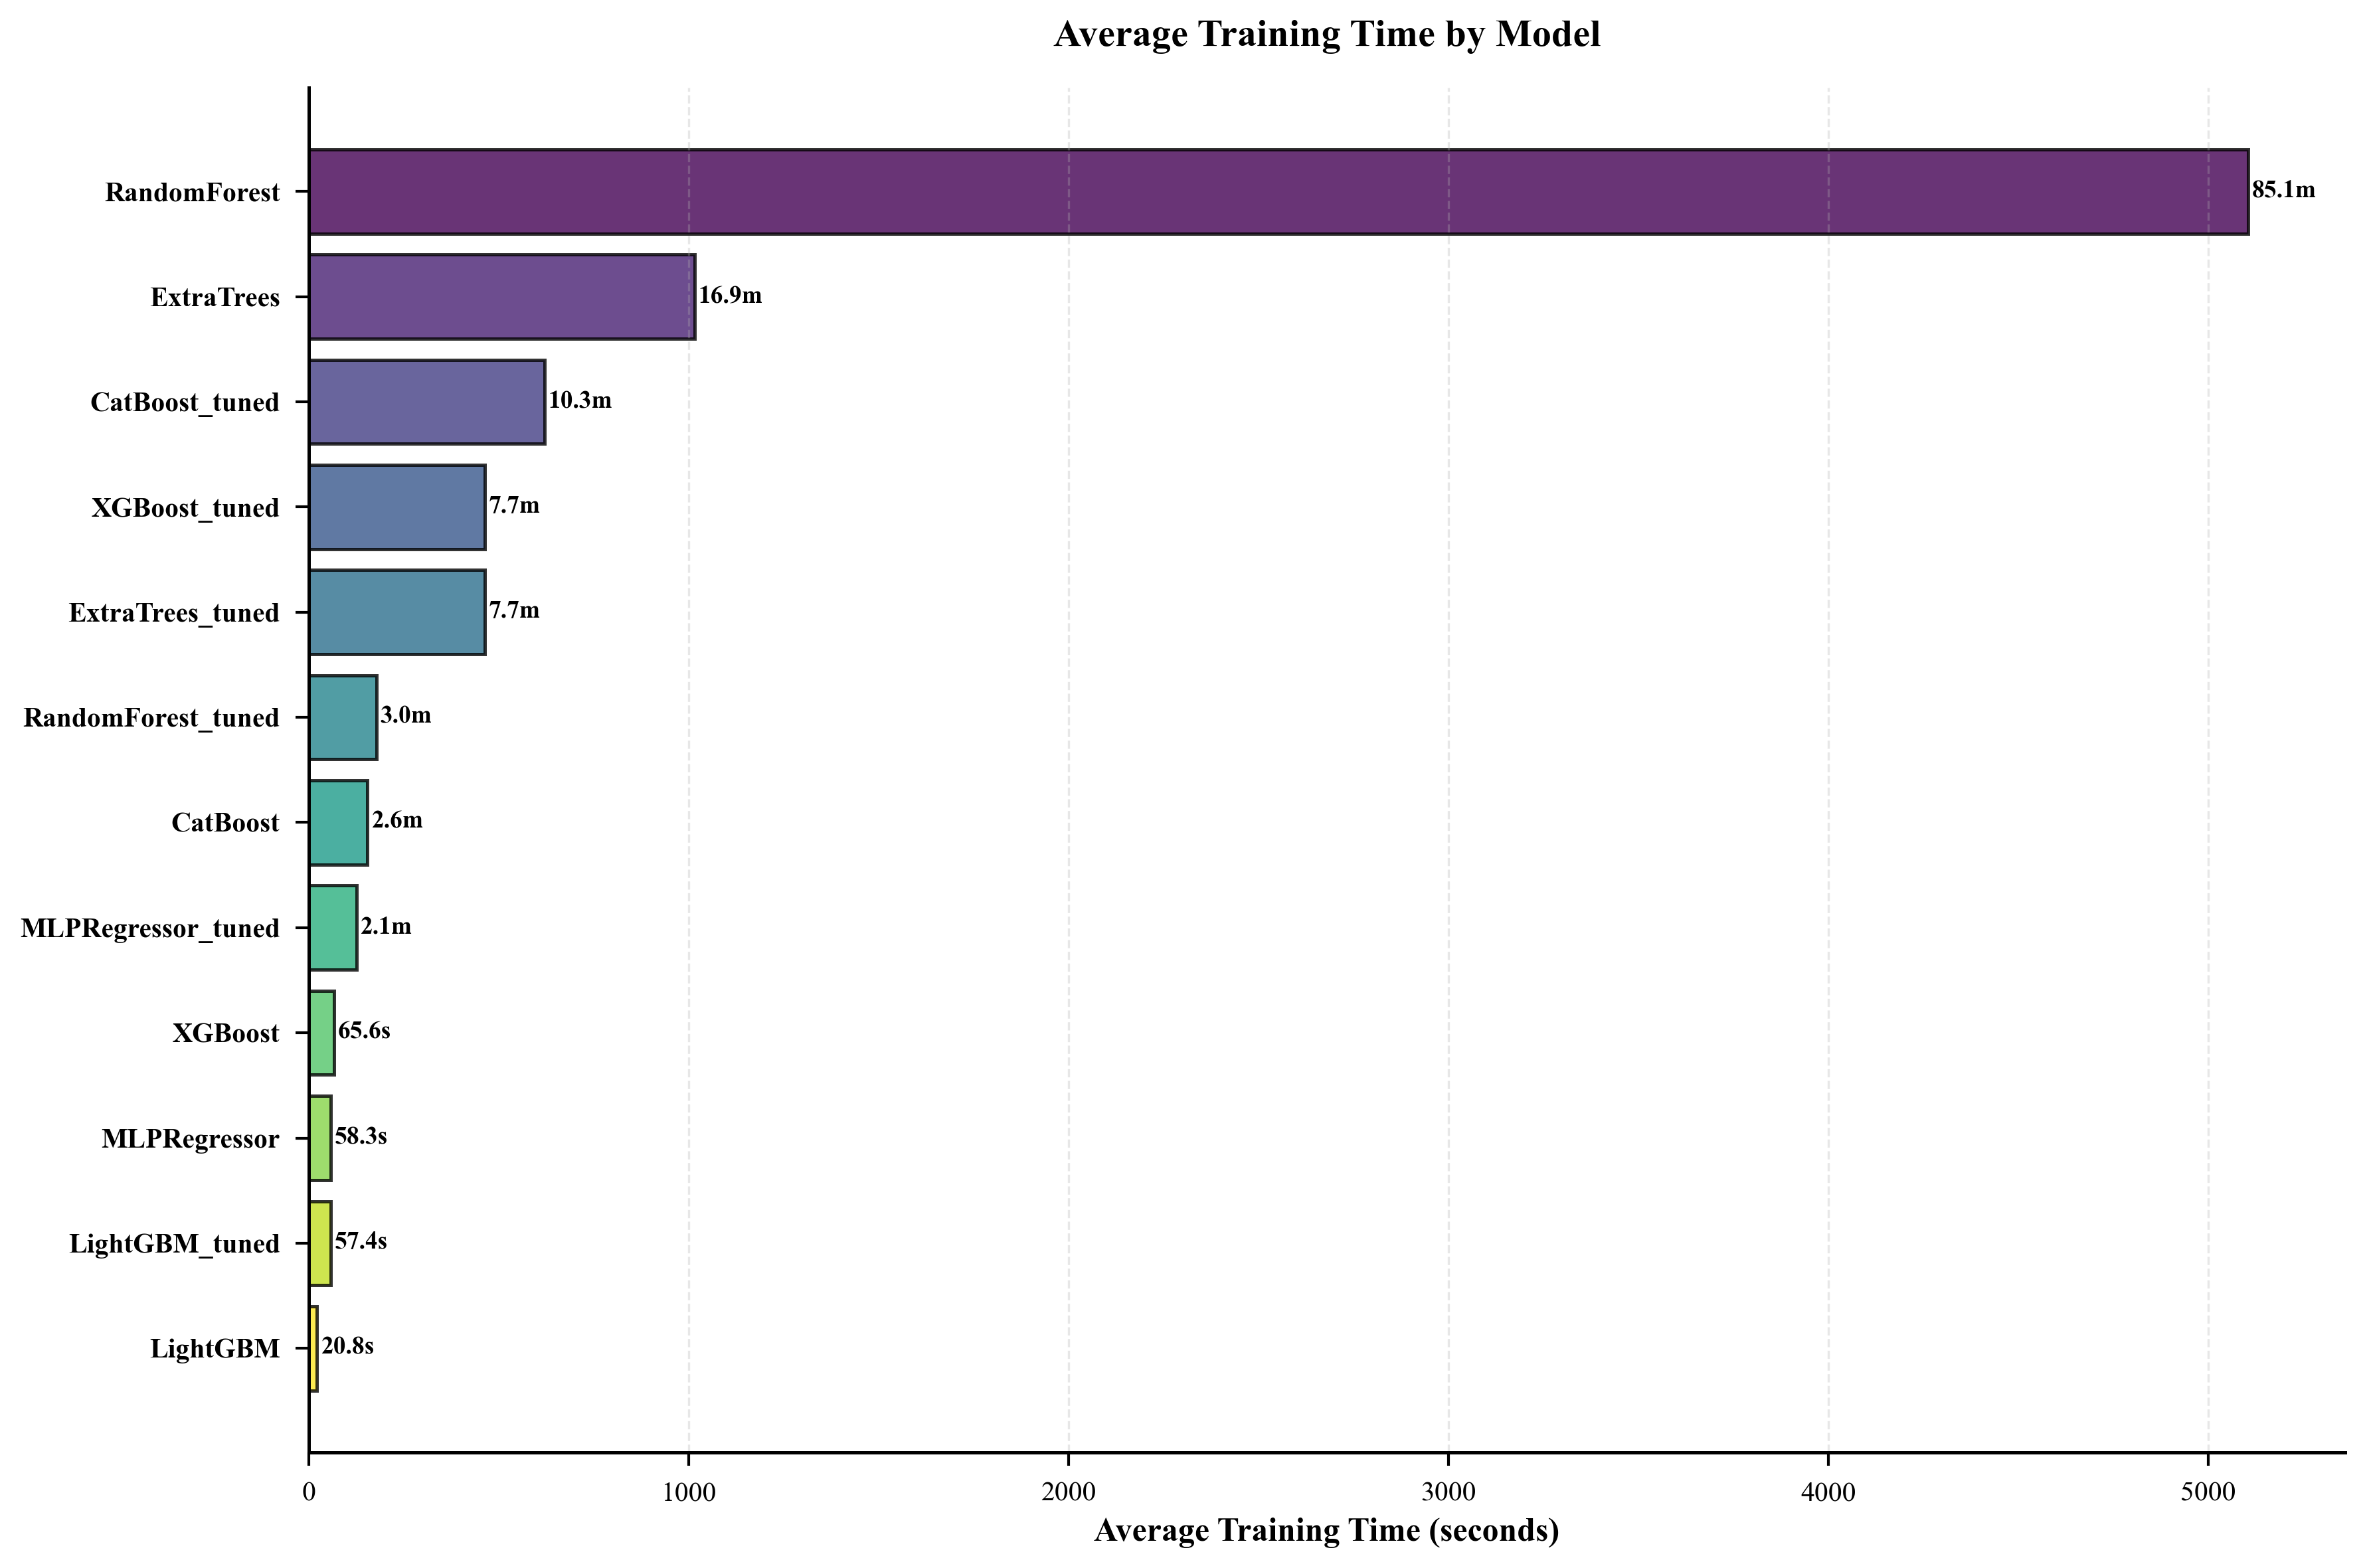

💾 Saved: results/figures/enhanced_training_time.png


In [12]:
# Aggregate training time by model
time_by_model = df.groupby('model')['train_time_seconds'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
colors = plt.cm.viridis(np.linspace(0, 1, len(time_by_model)))
bars = ax.barh(time_by_model.index, time_by_model.values, color=colors, edgecolor='black', alpha=0.8, linewidth=1.2)
ax.set_xlabel('Average Training Time (seconds)', fontsize=12, fontweight='bold')
ax.set_title('Average Training Time by Model', fontsize=14, fontweight='bold', pad=15)
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x', linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add value labels
for bar, val in zip(bars, time_by_model.values):
    if val > 100:
        label = f'{val/60:.1f}m'
    else:
        label = f'{val:.1f}s'
    ax.text(val + 10, bar.get_y() + bar.get_height()/2, label, va='center', fontsize=9, fontweight='bold')

plt.setp(ax.get_yticklabels(), fontweight='bold')
plt.tight_layout()
plt.savefig('../results/figures/enhanced_training_time.png', dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: results/figures/enhanced_training_time.png")

---
## 📉 RMSE Comparison

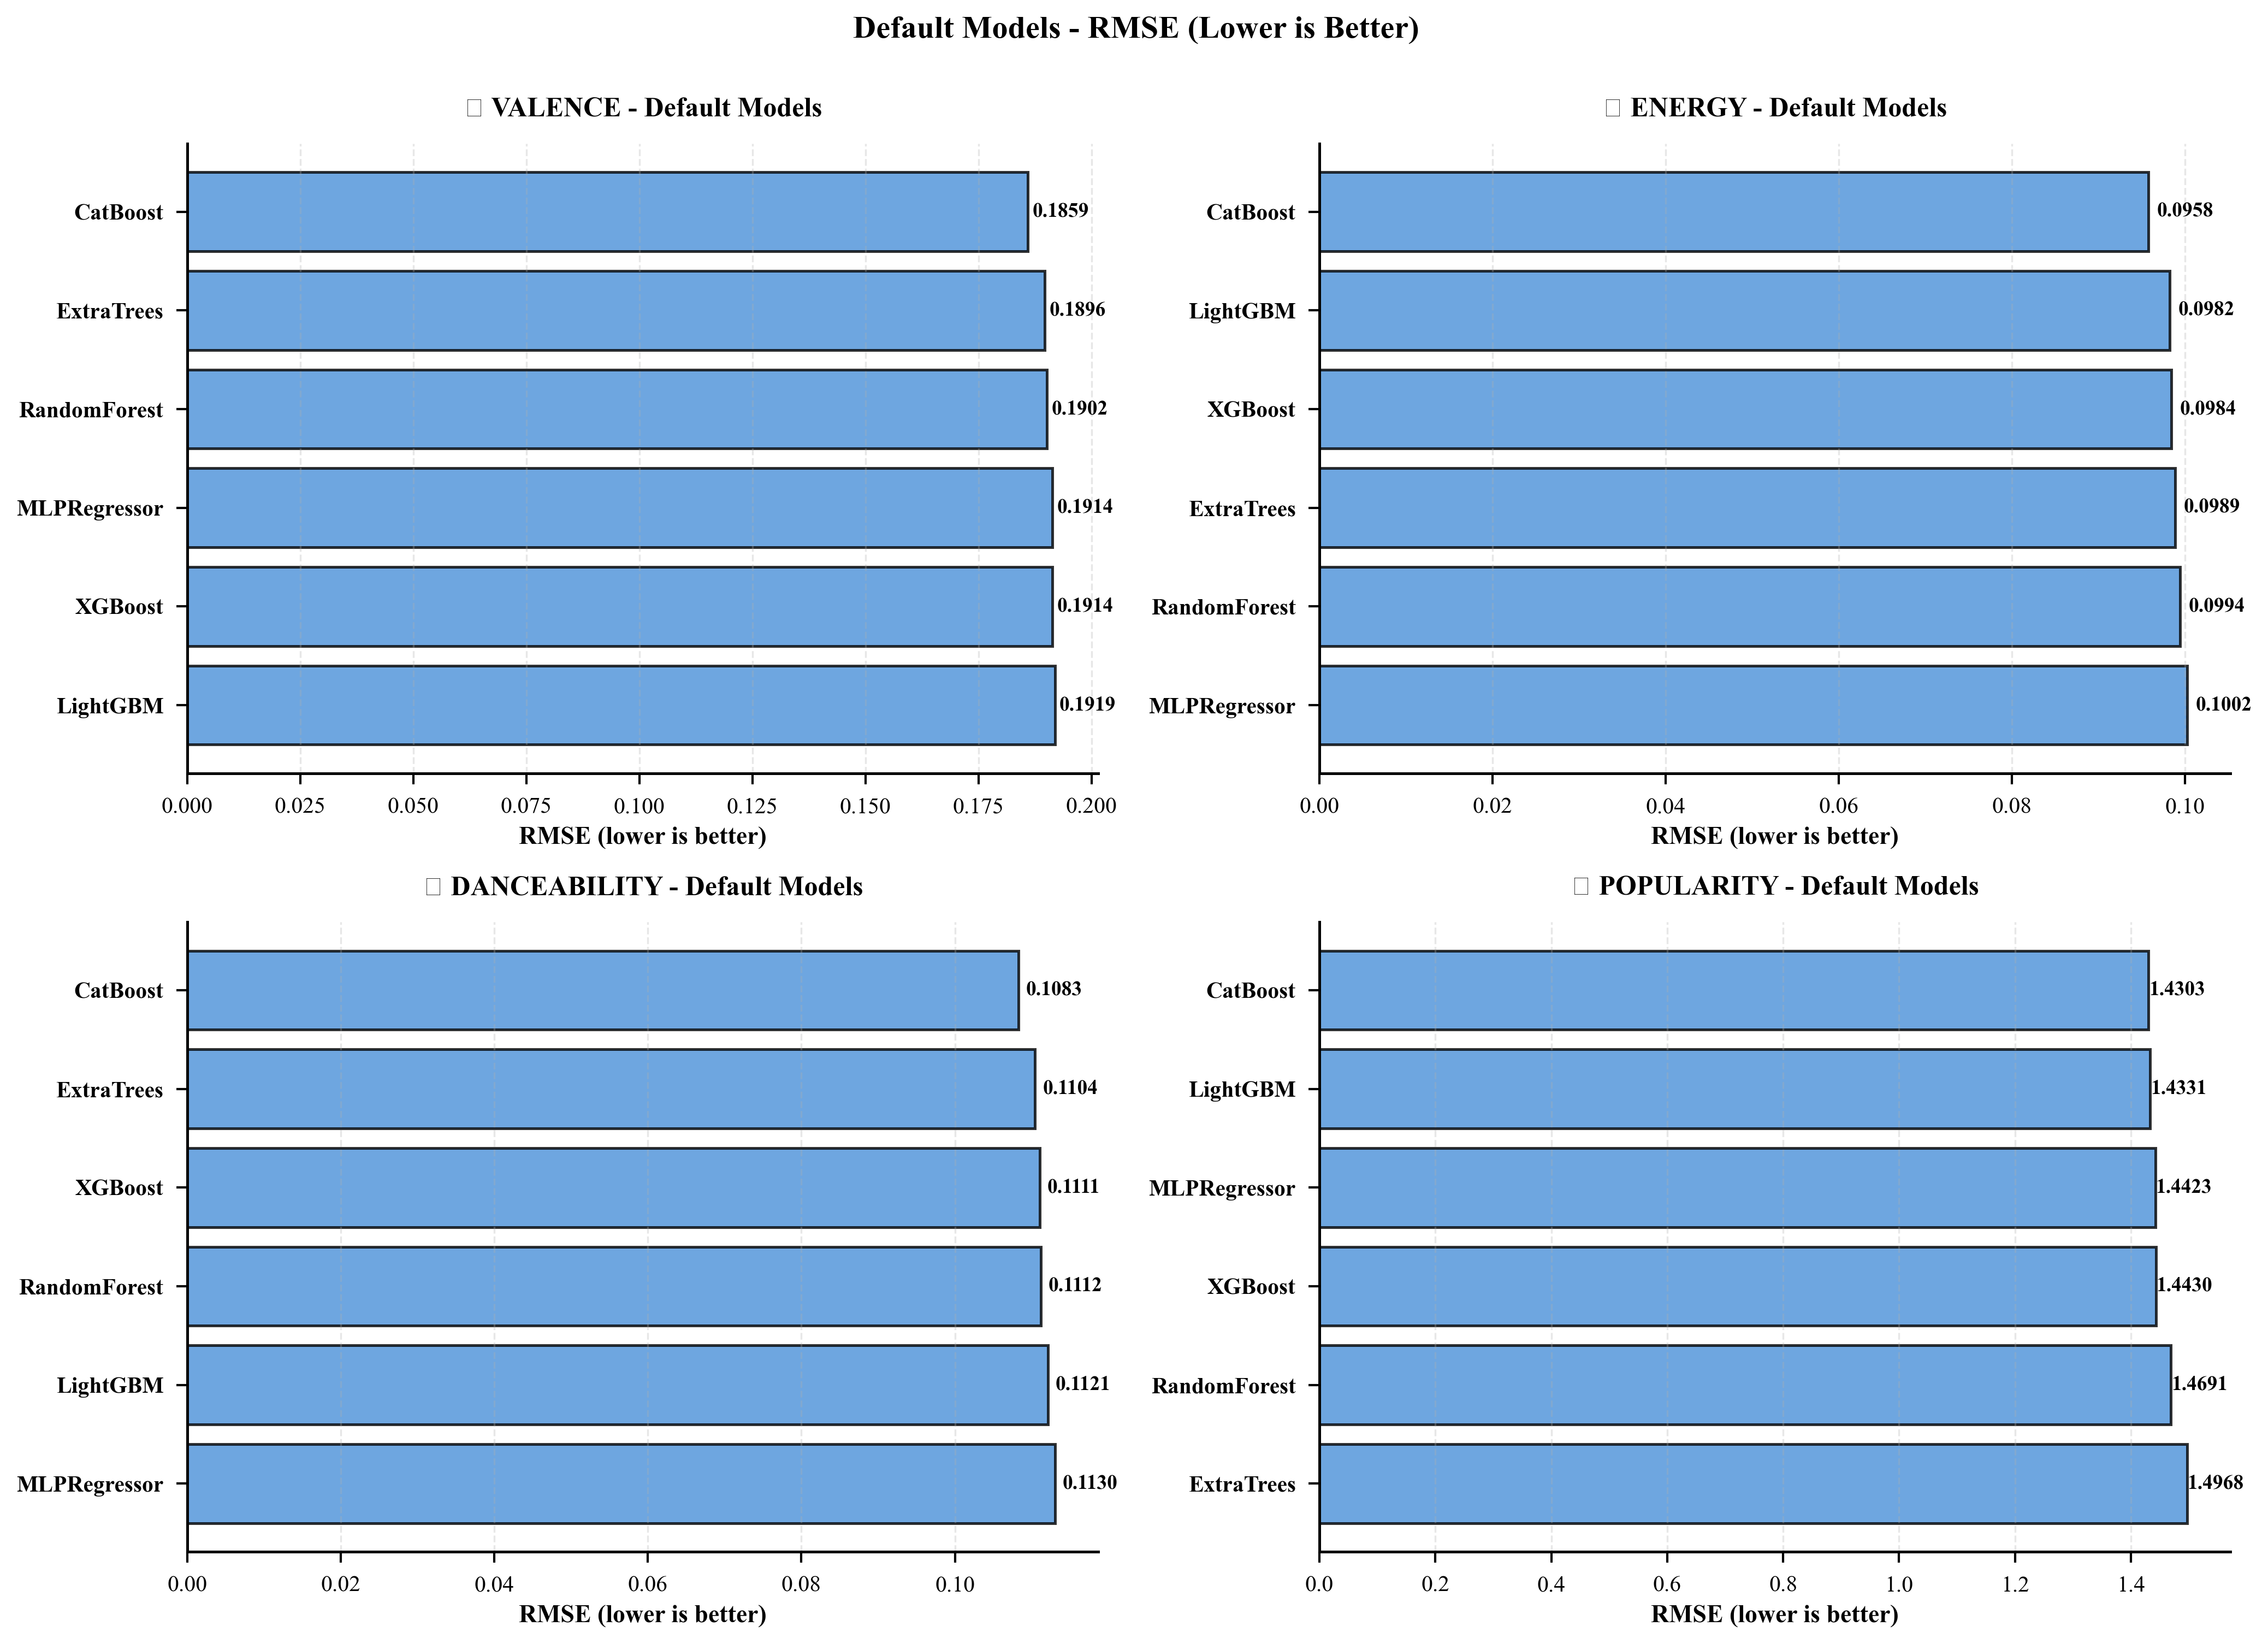

💾 Saved: results/figures/enhanced_default_rmse.png


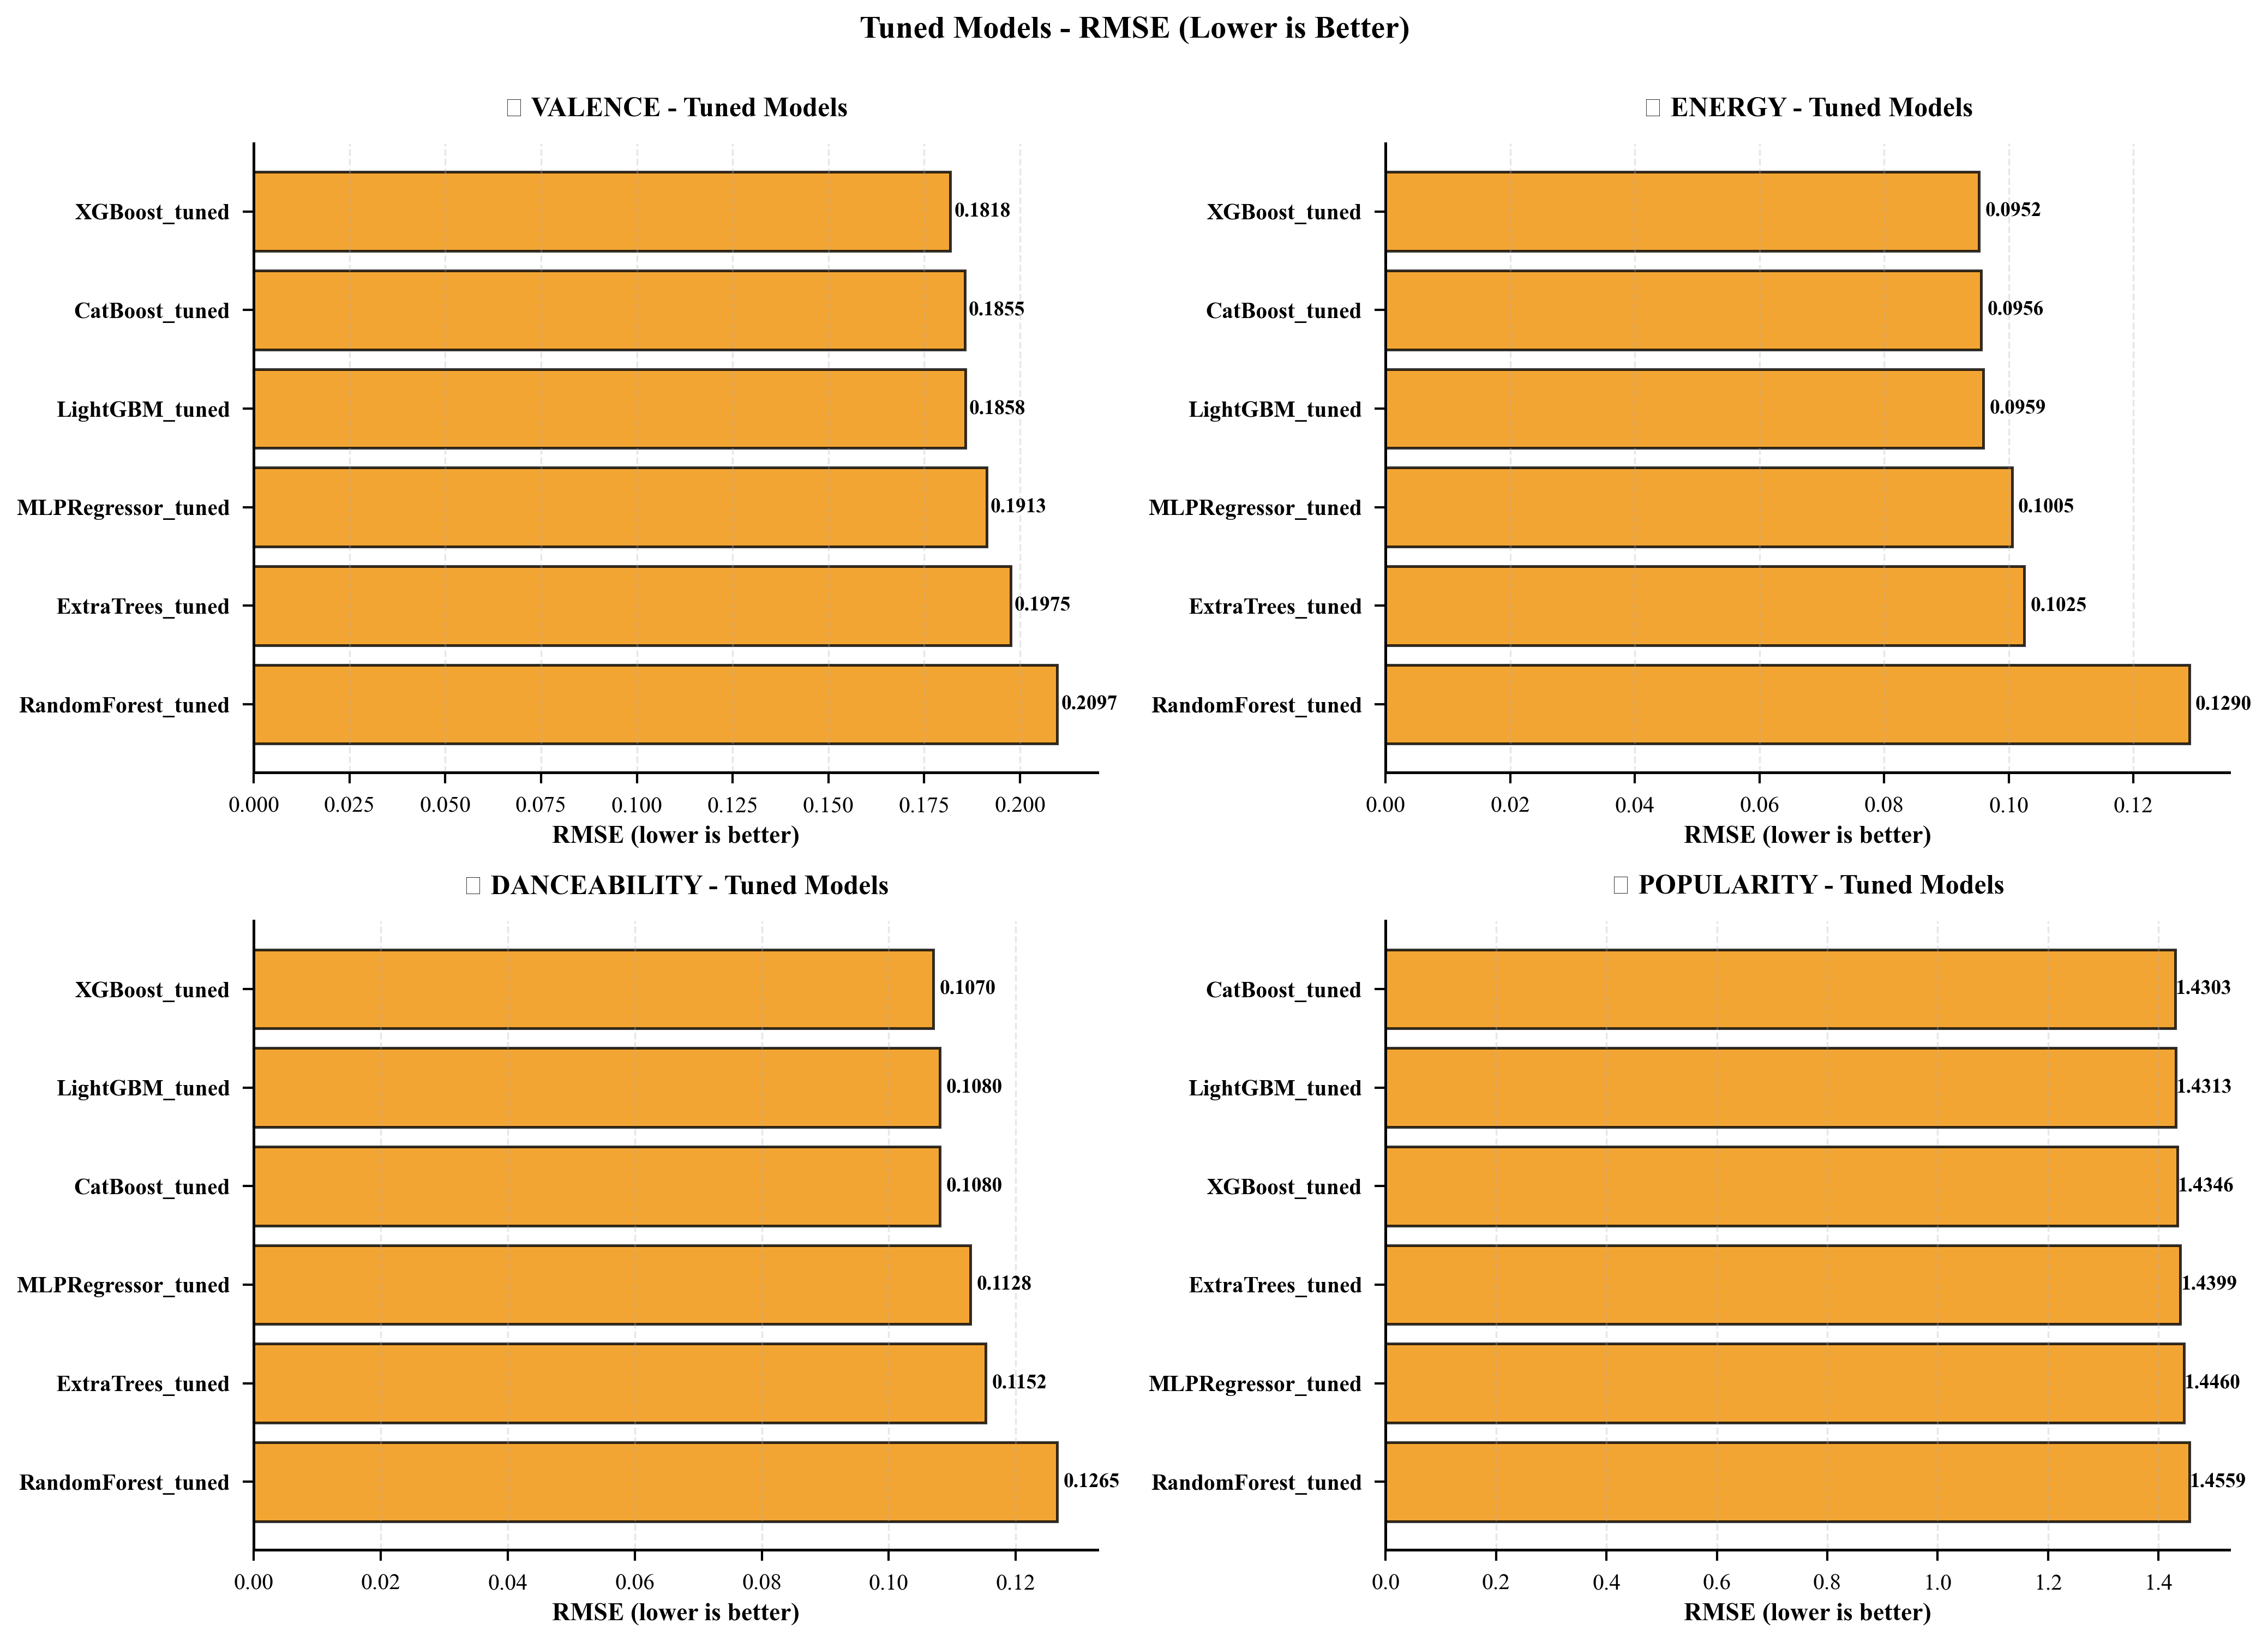

💾 Saved: results/figures/enhanced_tuned_rmse.png


In [13]:
# Create separate RMSE comparison for default and tuned models
targets = ['valence', 'energy', 'danceability', 'popularity']
emojis = ['🎭', '⚡', '💃', '🌟']

# Default models RMSE
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, target, emoji in zip(axes.flatten(), targets, emojis):
    top_models = df_default[df_default['target'] == target].nsmallest(6, 'rmse')
    
    bars = ax.barh(top_models['model'], top_models['rmse'], color='#4A90D9', 
                   edgecolor='black', alpha=0.8, linewidth=1.2)
    ax.set_xlabel('RMSE (lower is better)', fontsize=11, fontweight='bold')
    ax.set_title(f'{emoji} {target.upper()} - Default Models', fontsize=12, fontweight='bold', pad=12)
    ax.grid(True, alpha=0.3, axis='x', linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add value labels
    for bar, val in zip(bars, top_models['rmse']):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.4f}', 
                va='center', fontsize=9, fontweight='bold')
    
    ax.invert_yaxis()
    plt.setp(ax.get_yticklabels(), fontweight='bold')

plt.suptitle('Default Models - RMSE (Lower is Better)', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('../results/figures/enhanced_default_rmse.png', dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: results/figures/enhanced_default_rmse.png")

# Tuned models RMSE
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, target, emoji in zip(axes.flatten(), targets, emojis):
    top_models = df_tuned[df_tuned['target'] == target].nsmallest(6, 'rmse')
    
    bars = ax.barh(top_models['model'], top_models['rmse'], color='#F18F01', 
                   edgecolor='black', alpha=0.8, linewidth=1.2)
    ax.set_xlabel('RMSE (lower is better)', fontsize=11, fontweight='bold')
    ax.set_title(f'{emoji} {target.upper()} - Tuned Models', fontsize=12, fontweight='bold', pad=12)
    ax.grid(True, alpha=0.3, axis='x', linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Add value labels
    for bar, val in zip(bars, top_models['rmse']):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.4f}', 
                va='center', fontsize=9, fontweight='bold')
    
    ax.invert_yaxis()
    plt.setp(ax.get_yticklabels(), fontweight='bold')

plt.suptitle('Tuned Models - RMSE (Lower is Better)', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('../results/figures/enhanced_tuned_rmse.png', dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: results/figures/enhanced_tuned_rmse.png")

---
## 🔬 Default vs Tuned Models Comparison

In [14]:
# Compare default vs tuned versions
tuned_models = df[df['model'].str.contains('_tuned')].copy()
tuned_models['base_model'] = tuned_models['model'].str.replace('_tuned', '')

default_models = df[~df['model'].str.contains('_tuned')].copy()
default_models['base_model'] = default_models['model']

# Merge to compare
comparison = tuned_models.merge(
    default_models[['target', 'base_model', 'r2', 'rmse']], 
    on=['target', 'base_model'], 
    suffixes=('_tuned', '_default')
)
comparison['r2_improvement'] = comparison['r2_tuned'] - comparison['r2_default']
comparison['rmse_improvement'] = comparison['rmse_default'] - comparison['rmse_tuned']  # Positive = better

# Display improvement summary
improvement_summary = comparison.groupby('base_model').agg({
    'r2_improvement': 'mean',
    'rmse_improvement': 'mean'
}).sort_values('r2_improvement', ascending=False)

print("🔧 Tuning Impact (Average across all targets):")
print("="*50)
styled_improvement = improvement_summary.style.format({
    'r2_improvement': '{:+.4f}',
    'rmse_improvement': '{:+.4f}'
}).set_caption(
    '🔧 Tuning Impact: Positive = Improvement'
).set_table_styles([
    {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]},
])
display(styled_improvement)

🔧 Tuning Impact (Average across all targets):


,r2_improvement,rmse_improvement
base_model,,
XGBoost,+0.0274,+0.0063
LightGBM,+0.0195,+0.0036
CatBoost,+0.0011,+0.0002
MLPRegressor,-0.0010,-0.0009
ExtraTrees,-0.0058,+0.0101
RandomForest,-0.0865,-0.0128


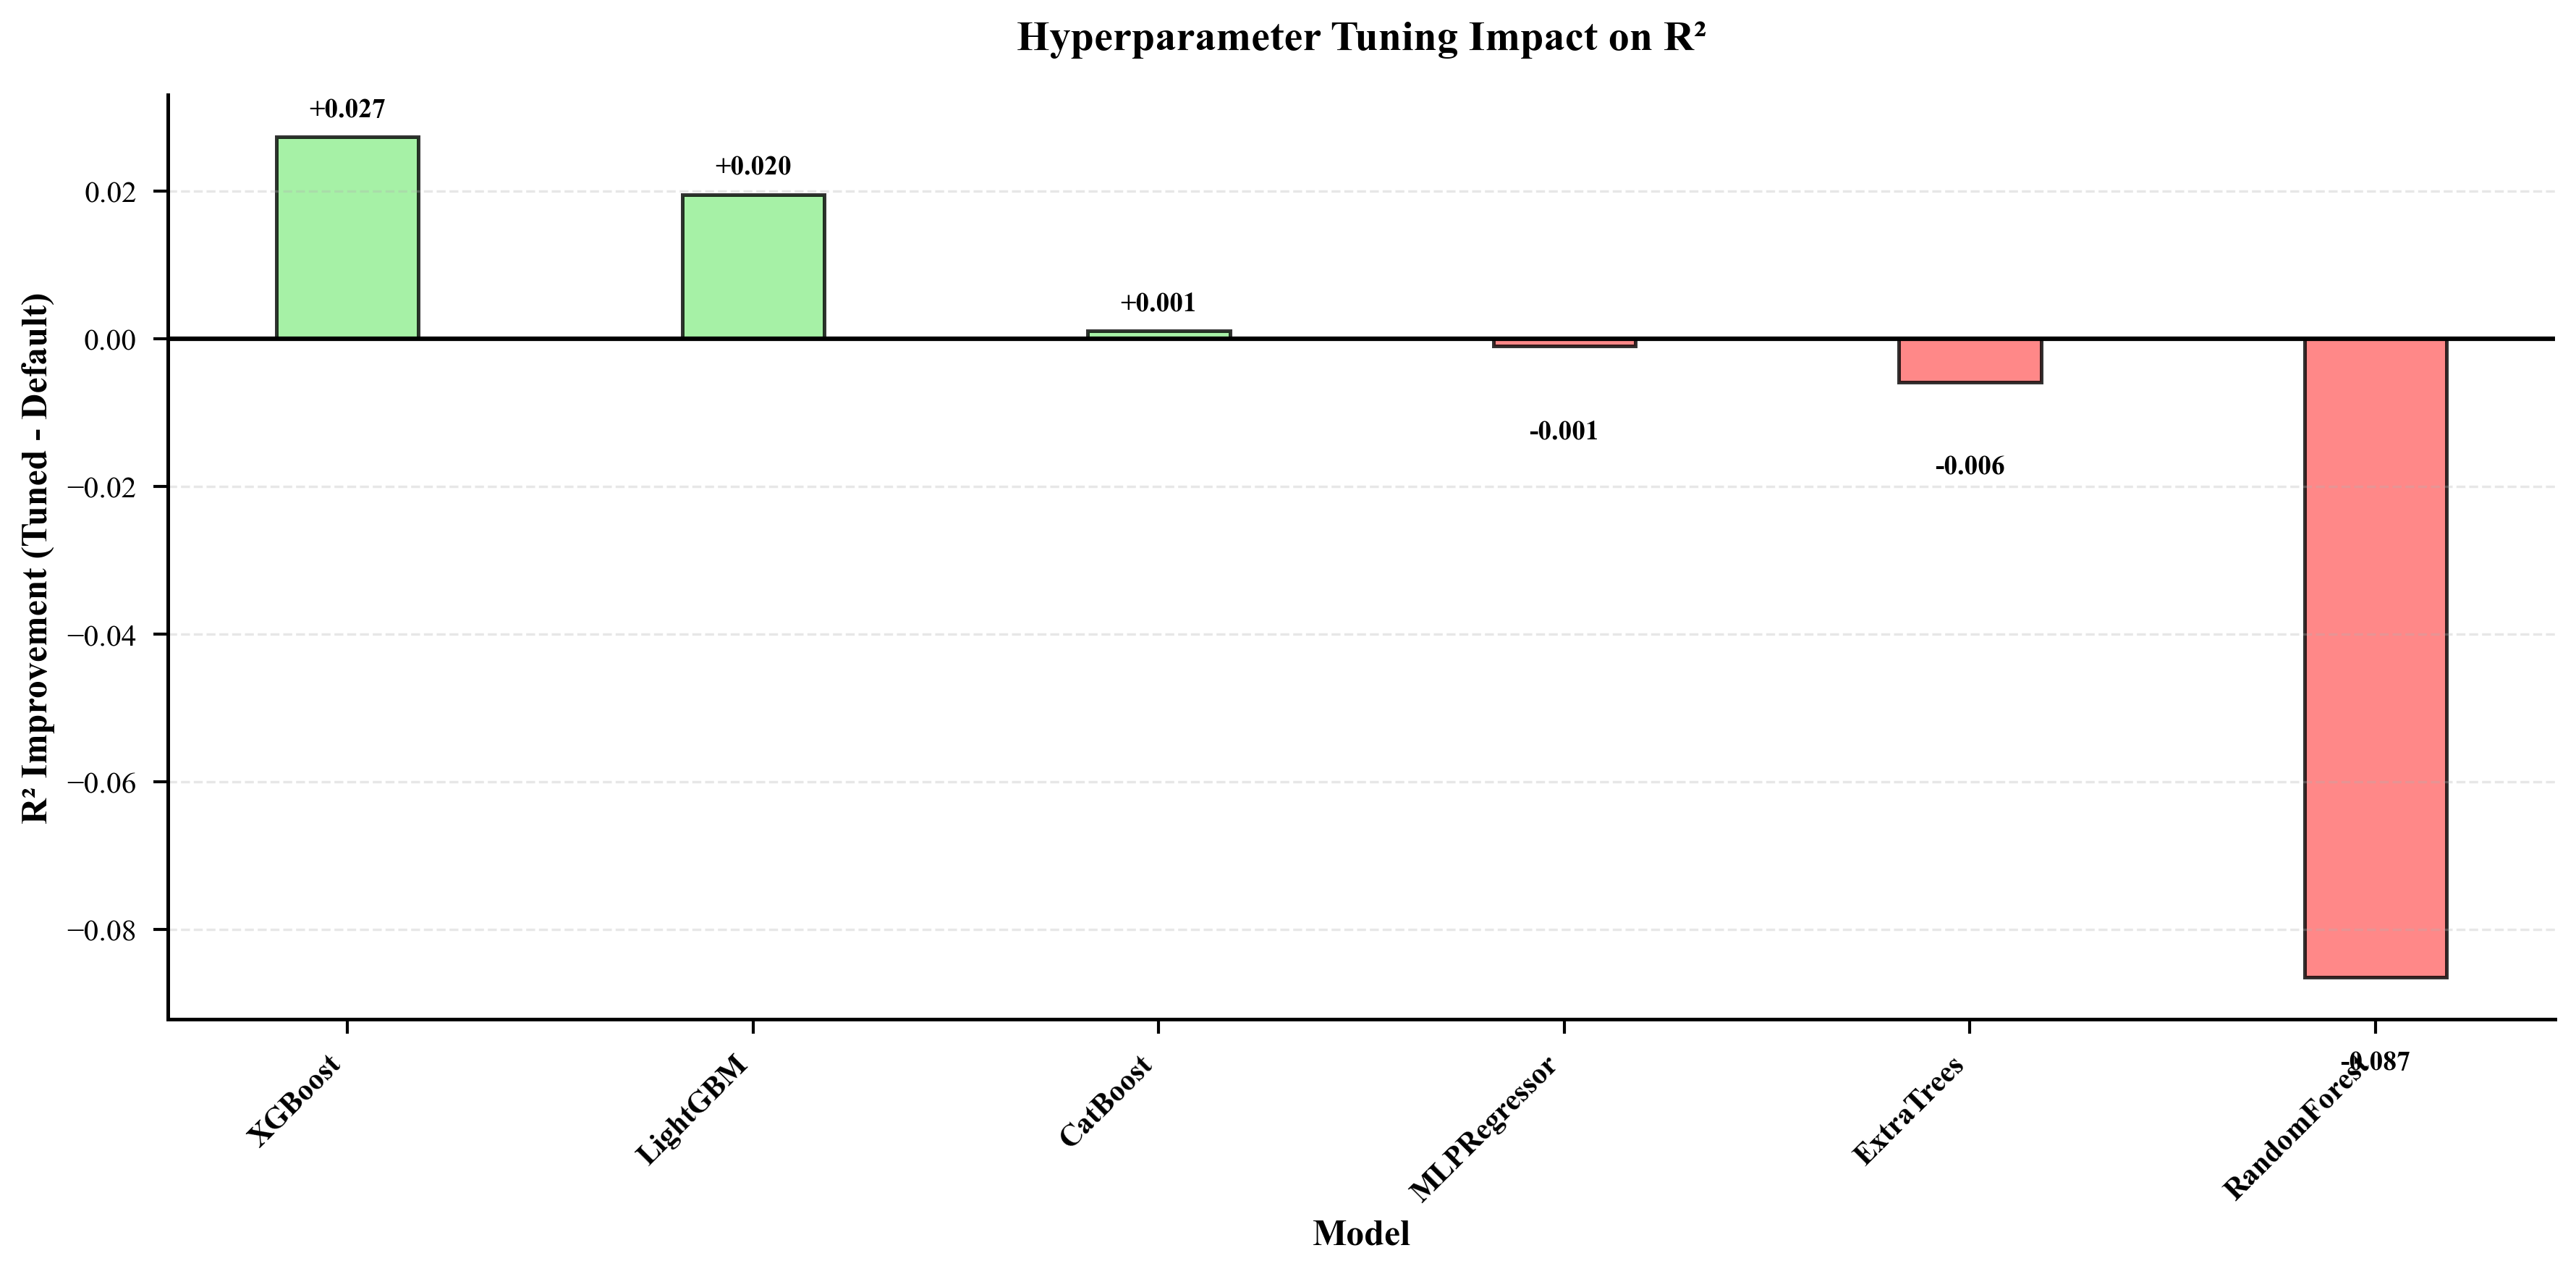

💾 Saved: results/figures/enhanced_tuning_impact.png


In [15]:
# Visualize tuning impact
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(improvement_summary))
width = 0.35

bars = ax.bar(x, improvement_summary['r2_improvement'], width, 
              color=['#90EE90' if v > 0 else '#FF6B6B' for v in improvement_summary['r2_improvement']],
              edgecolor='black', alpha=0.8, linewidth=1.2)

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('R² Improvement (Tuned - Default)', fontsize=12, fontweight='bold')
ax.set_title('Hyperparameter Tuning Impact on R²', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(improvement_summary.index, rotation=45, ha='right', fontweight='bold')
ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
ax.grid(True, alpha=0.3, axis='y', linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add value labels
for bar, val in zip(bars, improvement_summary['r2_improvement']):
    y_pos = val + 0.002 if val >= 0 else val - 0.01
    ax.text(bar.get_x() + bar.get_width()/2, y_pos, f'{val:+.3f}', 
            ha='center', va='bottom' if val >= 0 else 'top', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/figures/enhanced_tuning_impact.png', dpi=300, bbox_inches='tight')
plt.show()
print("💾 Saved: results/figures/enhanced_tuning_impact.png")

---
## 📋 Complete Results Table (All Models, All Targets)

In [16]:
# Create comprehensive tables separated by default and tuned
full_table = df[['target', 'model', 'r2', 'rmse', 'mae', 'explained_variance', 
                 'pred_mean', 'pred_std', 'residual_mean', 'residual_std', 'train_time_seconds']].copy()

# Default models
default_table = full_table[~full_table['model'].str.contains('_tuned')].copy()
default_table = default_table.sort_values(['target', 'r2'], ascending=[True, False])

# Tuned models
tuned_table = full_table[full_table['model'].str.contains('_tuned')].copy()
tuned_table = tuned_table.sort_values(['target', 'r2'], ascending=[True, False])

def color_by_target(val):
    colors = {
        'valence': 'background-color: #E8F4FD',
        'energy': 'background-color: #FDF4E8',
        'danceability': 'background-color: #F4E8FD',
        'popularity': 'background-color: #E8FDF4'
    }
    return colors.get(val, '')

print("="*80)
print("DEFAULT MODELS - COMPLETE RESULTS")
print("="*80)

styled_default = default_table.style.format({
    'r2': '{:.4f}',
    'rmse': '{:.4f}',
    'mae': '{:.4f}',
    'explained_variance': '{:.4f}',
    'pred_mean': '{:.4f}',
    'pred_std': '{:.4f}',
    'residual_mean': '{:.4f}',
    'residual_std': '{:.4f}',
    'train_time_seconds': '{:.1f}'
}).applymap(color_by_target, subset=['target']).set_caption(
    '📋 Default Models - Complete Results'
).set_table_styles([
    {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]},
    {'selector': 'th', 'props': [('background-color', '#4A90D9'), ('color', 'white')]},
])

display(styled_default)

print("\n" + "="*80)
print("TUNED MODELS - COMPLETE RESULTS")
print("="*80)

styled_tuned = tuned_table.style.format({
    'r2': '{:.4f}',
    'rmse': '{:.4f}',
    'mae': '{:.4f}',
    'explained_variance': '{:.4f}',
    'pred_mean': '{:.4f}',
    'pred_std': '{:.4f}',
    'residual_mean': '{:.4f}',
    'residual_std': '{:.4f}',
    'train_time_seconds': '{:.1f}'
}).applymap(color_by_target, subset=['target']).set_caption(
    '🔧 Tuned Models - Complete Results'
).set_table_styles([
    {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]},
    {'selector': 'th', 'props': [('background-color', '#F18F01'), ('color', 'white')]},
])

display(styled_tuned)

DEFAULT MODELS - COMPLETE RESULTS


,target,model,r2,rmse,mae,explained_variance,pred_mean,pred_std,residual_mean,residual_std,train_time_seconds
74,danceability,CatBoost,0.5998,0.1083,0.0854,0.5998,0.5303,0.1314,-0.0013,0.1082,153.4
68,danceability,ExtraTrees,0.5834,0.1104,0.0852,0.5834,0.5289,0.1212,0.0001,0.1104,996.8
72,danceability,XGBoost,0.5787,0.1111,0.0875,0.5788,0.5305,0.1330,-0.0015,0.1110,64.7
66,danceability,RandomForest,0.5778,0.1112,0.0869,0.5779,0.5295,0.1235,-0.0005,0.1112,4618.2
76,danceability,LightGBM,0.5707,0.1121,0.0888,0.5708,0.5305,0.1268,-0.0015,0.1121,20.8
82,danceability,MLPRegressor,0.5638,0.1130,0.0891,0.5638,0.5306,0.1366,-0.0016,0.1130,68.3
46,energy,CatBoost,0.8470,0.0958,0.0721,0.8470,0.6698,0.2238,0.0005,0.0958,149.0
48,energy,LightGBM,0.8390,0.0982,0.0740,0.8390,0.6697,0.2226,0.0007,0.0982,20.6
44,energy,XGBoost,0.8383,0.0984,0.0740,0.8383,0.6699,0.2248,0.0004,0.0984,63.2
40,energy,ExtraTrees,0.8369,0.0989,0.0731,0.8370,0.6686,0.2185,0.0017,0.0989,1006.1



TUNED MODELS - COMPLETE RESULTS


,target,model,r2,rmse,mae,explained_variance,pred_mean,pred_std,residual_mean,residual_std,train_time_seconds
73,danceability,XGBoost_tuned,0.6092,0.1070,0.0842,0.6092,0.5300,0.1298,-0.0010,0.1070,478.8
77,danceability,LightGBM_tuned,0.6016,0.1080,0.0851,0.6016,0.5304,0.1315,-0.0014,0.1080,55.7
75,danceability,CatBoost_tuned,0.6015,0.1080,0.0851,0.6016,0.5305,0.1315,-0.0015,0.1080,670.2
83,danceability,MLPRegressor_tuned,0.5650,0.1128,0.0890,0.5654,0.5259,0.1352,0.0031,0.1128,134.1
69,danceability,ExtraTrees_tuned,0.5464,0.1152,0.0916,0.5464,0.5295,0.1146,-0.0005,0.1152,459.2
67,danceability,RandomForest_tuned,0.4532,0.1265,0.1017,0.4532,0.5288,0.0888,0.0002,0.1265,170.5
45,energy,XGBoost_tuned,0.8487,0.0952,0.0716,0.8488,0.6696,0.2224,0.0007,0.0952,411.7
47,energy,CatBoost_tuned,0.8476,0.0956,0.0718,0.8476,0.6695,0.2244,0.0008,0.0956,652.4
49,energy,LightGBM_tuned,0.8466,0.0959,0.0723,0.8466,0.6696,0.2235,0.0007,0.0959,46.6
55,energy,MLPRegressor_tuned,0.8314,0.1005,0.0759,0.8314,0.6709,0.2249,-0.0006,0.1005,173.8


---
## 🎯 Final Recommendations

In [17]:
# Get top 2 models per target for both default and tuned
recommendations = []
targets = ['valence', 'energy', 'danceability', 'popularity']

print("="*80)
print("🎯 FINAL RECOMMENDATIONS")
print("="*80)

for target in targets:
    print(f"\n{target.upper()}:")
    print("-" * 60)
    
    # Top default model
    top_default = df_default[df_default['target'] == target].nlargest(1, 'r2').iloc[0]
    print(f"  Default: {top_default['model']}")
    print(f"    R² = {top_default['r2']:.4f} | RMSE = {top_default['rmse']:.4f} | Time = {top_default['train_time_seconds']:.1f}s")
    
    # Top tuned model
    top_tuned = df_tuned[df_tuned['target'] == target].nlargest(1, 'r2').iloc[0]
    print(f"  Tuned:   {top_tuned['model']}")
    print(f"    R² = {top_tuned['r2']:.4f} | RMSE = {top_tuned['rmse']:.4f} | Time = {top_tuned['train_time_seconds']:.1f}s")
    
    # Improvement
    r2_imp = top_tuned['r2'] - top_default['r2']
    rmse_imp = top_default['rmse'] - top_tuned['rmse']
    print(f"  Improvement: R² {r2_imp:+.4f} | RMSE {rmse_imp:+.4f}")
    
    # Add to recommendations
    rec_default = top_default[['target', 'model', 'r2', 'rmse', 'train_time_seconds']].to_dict()
    rec_default['type'] = 'Default'
    recommendations.append(rec_default)
    
    rec_tuned = top_tuned[['target', 'model', 'r2', 'rmse', 'train_time_seconds']].to_dict()
    rec_tuned['type'] = 'Tuned'
    recommendations.append(rec_tuned)

# Create recommendations dataframe
rec_df = pd.DataFrame(recommendations)
rec_df = rec_df[['target', 'type', 'model', 'r2', 'rmse', 'train_time_seconds']]

print("\n" + "="*80)
print("RECOMMENDATIONS TABLE")
print("="*80)

styled_rec = rec_df.style.format({
    'r2': '{:.4f}',
    'rmse': '{:.4f}',
    'train_time_seconds': '{:.1f}s'
}).set_caption('🎯 Final Model Recommendations').set_table_styles([
    {'selector': 'caption', 'props': [('font-size', '18px'), ('font-weight', 'bold'), ('color', '#2E86AB')]},
    {'selector': 'th', 'props': [('background-color', '#2E86AB'), ('color', 'white')]},
])

display(styled_rec)

🎯 FINAL RECOMMENDATIONS

VALENCE:
------------------------------------------------------------
  Default: CatBoost
    R² = 0.4414 | RMSE = 0.1859 | Time = 161.1s
  Tuned:   XGBoost_tuned
    R² = 0.4659 | RMSE = 0.1818 | Time = 767.2s
  Improvement: R² +0.0245 | RMSE +0.0041

ENERGY:
------------------------------------------------------------
  Default: CatBoost
    R² = 0.8470 | RMSE = 0.0958 | Time = 149.0s
  Tuned:   XGBoost_tuned
    R² = 0.8487 | RMSE = 0.0952 | Time = 411.7s
  Improvement: R² +0.0017 | RMSE +0.0005

DANCEABILITY:
------------------------------------------------------------
  Default: CatBoost
    R² = 0.5998 | RMSE = 0.1083 | Time = 153.4s
  Tuned:   XGBoost_tuned
    R² = 0.6092 | RMSE = 0.1070 | Time = 478.8s
  Improvement: R² +0.0094 | RMSE +0.0013

POPULARITY:
------------------------------------------------------------
  Default: CatBoost
    R² = 0.0783 | RMSE = 1.4303 | Time = 153.3s
  Tuned:   CatBoost_tuned
    R² = 0.0782 | RMSE = 1.4303 | Time = 491.

,target,type,model,r2,rmse,train_time_seconds
0,valence,Default,CatBoost,0.4414,0.1859,161.1s
1,valence,Tuned,XGBoost_tuned,0.4659,0.1818,767.2s
2,energy,Default,CatBoost,0.8470,0.0958,149.0s
3,energy,Tuned,XGBoost_tuned,0.8487,0.0952,411.7s
4,danceability,Default,CatBoost,0.5998,0.1083,153.4s
5,danceability,Tuned,XGBoost_tuned,0.6092,0.1070,478.8s
6,popularity,Default,CatBoost,0.0783,1.4303,153.3s
7,popularity,Tuned,CatBoost_tuned,0.0782,1.4303,491.2s


---
## ✅ Next Steps

Based on this analysis:

1. **Run test evaluation** on the recommended models (one-time final evaluation)
2. **Feature importance analysis** for the winning models
3. **Archive Experiment 1 results** before starting Experiment 2 (with artist features)
4. **Document findings** for thesis